## Notebook which investigates the neuro specific significant variants and tries to explain their effect 
- Use a subset of the variant sequences to find motifs overlapping the significant variants 
  1. Find the significant variants in the dataset 
  2. Neuro focused significant variants
  3. Create variant map derived ref and alt sequence table (for each variant a sequence for ref and alt which is variant_pos +- window_size bp)
  4. Create Fimo input fasta (each variant has ID_ref and ID_alt columns) (We cannot take ref id, because this would be not unique)
  5. Run Fimo on the sequences
  6. Filter for significant results 
  7. Map the significant results back to the variant map derived table and transform the fimo start and end back to the original sequence (for plotting and variant pos overlapping)
  8. Check which motifs are overlapping the significant variants
  9. Compute the proportion of neuro specific significant variants which are overlapping the motifs
  10. Plot the results 

In [1]:
import pandas as pd
import numpy as np
import yaml
import os
from collections import defaultdict
from importlib import reload
import math # check for nan
import matplotlib.pyplot as plt # plt.show()

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf
reload(hf)
# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

In [2]:
col_name = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class' # SNV
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'

In [3]:
# helpful functions

def get_gene_name(header, with_controls=True):
    """Returns the gene name: cardiac_neuro_cava_random:SKI|ENSG00000157933.11|EH38E2778533_fwd_tile1-1 => SKI"""
    if 'cardiac_neuro_cava_random' not in header:
        if not with_controls:
            print(header)
            raise ValueError("Function only defined for tested headers")
        return "Not given - control sequence"


    if 'ALT_' in header:
        return header.split(":ALT_")[1].split('|')[0]

    if 'REF_' in header:
        return header.split(":REF_")[1].split('|')[0]

    return header.split(':')[1].split('|')[0]


# dict of chr number to refseq chromosome number
chrom_2_refseq = {"1": "NC_000001.11",
    "2": "NC_000002.12",
    "3": "NC_000003.12",
    "4": "NC_000004.12",
    "5": "NC_000005.10",
    "6": "NC_000006.12",
    "7": "NC_000007.14",
    "8": "NC_000008.11",
    "9": "NC_000009.12",
    "10": "NC_000010.11",
    "11": "NC_000011.10",
    "12": "NC_000012.12",
    "13": "NC_000013.11",
    "14": "NC_000014.9",
    "15": "NC_000015.10",
    "16": "NC_000016.10",
    "17": "NC_000017.11",
    "18": "NC_000018.10",
    "19": "NC_000019.10",
    "20": "NC_000020.11",
    "21": "NC_000021.9",
    "22": "NC_000022.11",
    "X": "NC_000023.11",
    "Y": "NC_000024.10"}

# get args with click: input file, seperator, ids of chr, pos, ref, alt in string
def create_speedy_chromosomes(user_string, seperator="-", indices=[0,1,2,3]):
    """
    Returns SPDI identifier for given variant
    spdi: refseq_chromosome:pos:ref:alt
    @params: indices: list of indices for chromosome, position, ref and alt in user_string
    """
    if len(user_string.split(seperator)) < 4:
        raise ValueError('Not enough indices given: Expected chrom, pos, ref, alt position in user_string')
    split_string = user_string.split(seperator)
    zero_based_position = int(split_string[indices[1]]) - 1 # (input: 1-based => 0-based)
    return f'{chrom_2_refseq[split_string[indices[0]]]}:{zero_based_position}:{split_string[indices[2]]}:{split_string[indices[3]]}'

# for sequence of fimo input
def get_variant_pos_sequences_for_ref_alt(row, sequence_column, window_size=10):
    """
    For each row get the sequence of variant_pos +- window_size
    """
    if row['variant_pos'] is None:
        return None
    variant_pos = row['variant_pos'][0] # e.g. variant_pos: [1]
    sequence = row[sequence_column]
    start = variant_pos - window_size
    end = variant_pos + window_size
    return sequence[start:end+1] # because end is exclusive

### Read Metadata: 

In [4]:
metadata_file = pd.read_csv(config['files']['creating']['datafreeze_table'], sep="\t", low_memory=False)

# add sequences without adapter:
metadata_file['sequence_with_adapter'] = metadata_file['sequence']
metadata_file['sequence'] = metadata_file['sequence_with_adapter'].apply(lambda x: x[15:-15])
print(metadata_file['sequence'].str.len().value_counts())
metadata_file.head()
metadata_file.columns

270    73846
Name: sequence, dtype: int64


Index(['header', 'sequence', 'tmp_label', 'name', 'category', 'class',
       'source', 'ref', 'variant_class', 'variant_pos', 'SPDI', 'allele',
       'info', 'tmp_matching_header', 'chr', 'start', 'end', 'region_name',
       'strand', 'tmp_region_id', 'tmp_open_NGN2_WTC11_NP_screen_regions',
       'tmp_chr_start_end', 'tmp_open_NGN2_WTC11_NP',
       'tmp_open_h1_neuro_dnase_screen', 'tmp_MPRA_primary_region_overlap',
       'tmp_MPRA_organoid_region_overlap', 'tmp_gene_name', 'tmp_gene_set',
       'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random',
       'sequence_with_adapter'],
      dtype='object')

In [5]:
gnomad_data_all_variants = pd.read_csv(config['files']['creating']['gnomad_data_all_variants'], sep="\t")
# add gnomad prefix to all the columns
gnomad_data_all_variants.columns = ['gnomad_' + col for col in gnomad_data_all_variants.columns]

gnomad_data_all_variants.columns

Index(['gnomad_header', 'gnomad_chrom', 'gnomad_pos', 'gnomad_ref',
       'gnomad_alt', 'gnomad_AF', 'gnomad_AC'],
      dtype='object')

In [6]:
import ast

# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x

# list columns col_variant_class, col_variant_pos, col_SPDI, col_allele,
list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]
# Apply the safe_eval function to the specified columns
for col in list_columns:
    metadata_file[col] = metadata_file[col].apply(safe_eval)

#### Compute Numbers for the overview table of the experiment (variants and regions per gene set)
- elements: sequences in the metadata table: 27472 (27199 unique)
- result in: `/home/kisa/coding/80K_MPRA/design_data/design_info/80K_design_numbers_per_gene_set.xlsx` (file)


In [7]:
# compute numbers of elements (use tmp_region_id)
metadata_element = metadata_file.loc[~metadata_file[col_allele].apply(hf.is_alternative)]
metadata_element # 27472
metadata_element['tmp_region_id'].nunique() # 27199

# deduplicated elements
metadata_element_deduplicated = metadata_element.drop_duplicates(subset='tmp_region_id', keep='first')

# table of duplicates in the tmp_region_id
duplicated_regions = metadata_element[metadata_element.duplicated(subset='tmp_region_id', keep=False)]
duplicated_regions[[col_name, 'tmp_region_id', 'chr', 'start', 'end', col_sequence]].sort_values('tmp_region_id')
print("Number of duplicated regions: (fwd and reverse): ", duplicated_regions.shape[0]) # 546
# finding: for all these duplicates with REF_ in the name: forward and reverse are designed (How to treat them?)
# duplicates:
duplicated_regions['name'].to_list()

# checking the set of sequences without REF_ in the name
duplicated_regions[~duplicated_regions[col_name].str.contains('REF_')].sort_values('tmp_region_id')[col_name].to_list()

# conclusion: smae genomoic region (some forward, some reverse) are designed (sometimes for different genes) => therefore same region (still no tiling found)
print("Found duplicated regions:")
print("conclusion: smae genomoic region (some forward, some reverse) are designed (sometimes for different genes) => therefore same region (still no tiling found)")

Number of duplicated regions: (fwd and reverse):  546
Found duplicated regions:
conclusion: smae genomoic region (some forward, some reverse) are designed (sometimes for different genes) => therefore same region (still no tiling found)


In [8]:
# number of regions per group
metadata_element_deduplicated.groupby(['tmp_is_cava', 'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_random'])['tmp_region_id'].size().reset_index()

,tmp_is_cava,tmp_is_neuro,tmp_is_cardiac,tmp_is_random,tmp_region_id
0,False,False,False,True,717
1,False,False,True,False,7544
2,False,True,False,False,16143
3,False,True,True,False,866
4,True,False,False,False,1610
5,True,False,True,False,111
6,True,True,False,False,179
7,True,True,True,False,29


In [9]:
# compute number of genes per class:
metadata_file[col_class].value_counts()
metadata_variant = metadata_file.loc[metadata_file[col_category] == 'variant']

# numbers of different genes (tmp_gene_name) per gene set (tmp_is_cava, tmp_is_neuro, tmp_is_cardiac, tmp_is_random)
metadata_variant.groupby(['tmp_is_cava', 'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_random'])['tmp_gene_name'].nunique().reset_index()

# add allele frequency from gnomad to the variant list:
metadata_variant_alt = metadata_file.loc[metadata_file[col_allele].apply(hf.is_alternative)]
print(f"All alternative sequences: {metadata_variant_alt[col_name].nunique()}")
gnomad_metadata_variant_alt = metadata_variant_alt.merge(gnomad_data_all_variants[['gnomad_header', 'gnomad_AF', 'gnomad_AC']], left_on=col_name, right_on='gnomad_header', how='inner')
print(f"All alternative sequences with gnomad annotation: {gnomad_metadata_variant_alt[col_name].nunique()}")

All alternative sequences: 46374
All alternative sequences with gnomad annotation: 46374


In [10]:
# add tmp_is_common_rare variant column
gnomad_metadata_variant_alt['tmp_is_common_rare'] = gnomad_metadata_variant_alt['gnomad_AF'] > 0.01

# add tmp_is_ultra_rare_singleton column
gnomad_metadata_variant_alt['tmp_is_ultra_rare_singleton'] = gnomad_metadata_variant_alt['gnomad_AF'] <= 0.01

# number of common and rare variants for each gene set (tmp_is_cava, tmp_is_neuro, tmp_is_cardiac, tmp_is_random)
gnomad_metadata_variant_alt.groupby(['tmp_is_cava', 'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_random'])['tmp_is_common_rare'].value_counts().reset_index(name='count')

,tmp_is_cava,tmp_is_neuro,tmp_is_cardiac,tmp_is_random,tmp_is_common_rare,count
0,False,False,False,True,False,3394
1,False,False,False,True,True,600
2,False,False,True,False,True,6840
3,False,False,True,False,False,6590
4,False,True,False,False,True,12351
5,False,True,False,False,False,6911
6,False,True,True,False,False,746
7,False,True,True,False,True,634
8,True,False,False,False,False,5662
9,True,False,False,False,True,1391


### Read element and variant based BCalm results => variant map derived table of BCalm results

In [11]:
# bcalm results bbmap:
variant_map = pd.read_csv(config['files']['final_design']['variant_table'], sep="\t", low_memory=False, header=None)
variant_map.columns = ['ID', 'Region', 'REF', 'ALT']
variant_map

# input_file_bcalm = '/home/kisa/coding/80K_MPRA/bc_MPRAlm_results/results/toptable_new_filtering_variant_controls_mendelian_NGN2.tsv'
input_file_bcalm = config['files']['creating']['bc_MPRAlm']
bcalm_variant = pd.read_csv(input_file_bcalm, sep="\t", low_memory=False)
bcalm_variant
if bcalm_variant.shape[0] != bcalm_variant['variant_id'].nunique():
    raise ValueError('Not all variants are unique in bc_MPRAlm results')
if variant_map.shape[0] != variant_map['ID'].nunique():
    raise ValueError('Not all variants are unique in variant_map results')

# only tested:
tested_bcalm_variant = bcalm_variant.loc[bcalm_variant['variant_id'].str.contains('cardiac_neuro_cava_random')]
print(f"Number of tested variants in bc_MPRAlm: {tested_bcalm_variant.shape[0]}")
print(f"Number of unique tested variants in bc_MPRAlm: {tested_bcalm_variant['variant_id'].nunique()}")

print(f'Tested variants with bc_MPRAlm: {tested_bcalm_variant.shape[0]}')
print(f'Significant tested variants with bc_MPRAlm: {tested_bcalm_variant.loc[tested_bcalm_variant["adj.P.Val"] < 0.05].shape[0]}')

# get chrom pos ref alt pattern
tested_bcalm_variant['chr_pos_ref_alt'] = tested_bcalm_variant['variant_id'].apply(hf.get_chrom_pos_ref_alt_pattern)
tested_bcalm_variant.loc[tested_bcalm_variant['chr_pos_ref_alt'] == "NA"]
# get SPDI
tested_bcalm_variant['SPDI'] = tested_bcalm_variant['chr_pos_ref_alt'].apply(lambda x: create_speedy_chromosomes(x, seperator="-", indices=[0,1,2,3]))
tested_bcalm_variant

# load element bc_MPRAlm results and add to the tested_bcalm_variant
columns_of_interest_bcalm = ['SPDI', 'logFC', 'adj.P.Val']
tested_bcalm_variant = tested_bcalm_variant[columns_of_interest_bcalm]
tested_bcalm_variant.columns = ['SPDI', 'variant_BCalm_logFC', 'variant_BCalm_adj.P.Val']

ValueError: Not all variants are unique in variant_map results

In [12]:
element_bcalm_df = pd.read_csv(config['files']['creating']['element_analysis_np_negative_neuron_vs_tested'], sep="\t", low_memory=False)
# rename columns variant_id => REF
element_bcalm_df = element_bcalm_df.rename(columns={'variant_id': 'REF', 'logFC': 'REF_BCalm_logFC'})

print(f"Number of unique variants in element_bcalm_df: {variant_map['ID'].nunique()}") # 46157 # 47044
print(f"Number of variants table: {variant_map.shape[0]}") # 46157 # 47044
# # read variant table
# variant_map = pd.read_csv(variant_table_bbmap_35, sep="\t", low_memory=False)
element_bcalm_variant_map = pd.merge(variant_map, element_bcalm_df, on='REF', how='inner')
# print(element_bcalm_variant_map.shape[0]) # 37615 # 38931
element_bcalm_variant_map['ID'].nunique() # 37603

element_bcalm_variant_map['chr_pos_ref_alt'] = element_bcalm_variant_map['ALT'].apply(hf.get_chrom_pos_ref_alt_pattern)
element_bcalm_variant_map['SPDI'] = element_bcalm_variant_map['chr_pos_ref_alt'].apply(lambda x: create_speedy_chromosomes(x, seperator="-", indices=[0,1,2,3]))
columns_of_interest_elements = ['SPDI', 'ID', 'REF', 'ALT', 'REF_BCalm_logFC']

# subset of columns
element_bcalm_variant_map = element_bcalm_variant_map[columns_of_interest_elements]
element_bcalm_variant_map.head()

Number of unique variants in element_bcalm_df: 47044
Number of variants table: 47044


,SPDI,ID,REF,ALT,REF_BCalm_logFC
0,NC_000001.11:2192365:T:G,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.466017
1,NC_000001.11:2193141:G:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.002283
2,NC_000001.11:2197933:C:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.375449
3,NC_000001.11:2198006:C:G,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.375449
4,NC_000001.11:2198045:G:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.375449


In [13]:
# combine variant results of bcalm and element analysis
variant_results_bcalm_unique_variants = pd.merge(element_bcalm_variant_map, tested_bcalm_variant, on='SPDI', how='inner')
print('Number of variants with BCalm results: ', variant_results_bcalm_unique_variants.ID.nunique()) # 37500
variant_results_bcalm_unique_variants
# rename columns:
# variant_BCalm_logFC, variant_BCalm_adj.P.Val, REF_BCalm_logFC
# to:
# variant_effect_BCalm_logFC, variant_effect_BCalm_adj_p_Val, reference_activity_BCalm_logFC
variant_results_bcalm_unique_variants.columns = ['SPDI', 'ID', 'REF', 'ALT', 'reference_activity_BCalm_logFC', 'variant_effect_BCalm_logFC', 'variant_effect_BCalm_adj_p_Val']
variant_results_bcalm_unique_variants.head()

Number of variants with BCalm results:  37512


,SPDI,ID,REF,ALT,reference_activity_BCalm_logFC,variant_effect_BCalm_logFC,variant_effect_BCalm_adj_p_Val
0,NC_000001.11:2192365:T:G,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.466017,0.004829,0.994254
1,NC_000001.11:2193141:G:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.002283,-0.074599,0.760278
2,NC_000001.11:2197933:C:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.375449,-0.028610,0.957113
3,NC_000001.11:2198006:C:G,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.375449,-0.060843,0.874930
4,NC_000001.11:2198045:G:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.375449,-0.065858,0.859649


#### Add the metadata information (sequences and variant positions) to the BCalm results
- get reference sequences using left join (on REF)
- add alt sequence and variant position using left join (on ALT)
- add 'tmp_gene_name', 'tmp_gene_set',
       'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random'

In [14]:
# subset of columns from metadata_file
columns_of_interest_metadata_reference = [col_name, col_sequence]
columns_of_interest_metadata_alternative = [col_name, col_sequence, col_variant_pos, 'tmp_gene_name', 'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random']

# left join metadata_file with variant_results_bcalm_unique_variants (REF)
variant_results_bcalm_unique_variants_sequences = variant_results_bcalm_unique_variants.merge(metadata_file[columns_of_interest_metadata_reference], left_on='REF', right_on=col_name, how='left')

# rename sequence to REF_sequence
variant_results_bcalm_unique_variants_sequences = variant_results_bcalm_unique_variants_sequences.rename(columns={col_sequence: 'REF_sequence'})
variant_results_bcalm_unique_variants_sequences = variant_results_bcalm_unique_variants_sequences.drop(columns=[col_name])

# left join metadata_file with variant_results_bcalm_unique_variants (ALT)
variant_results_bcalm_unique_variants_sequences = variant_results_bcalm_unique_variants_sequences.merge(metadata_file[columns_of_interest_metadata_alternative], left_on='ALT', right_on=col_name, how='left')
print(f"Number of na in ALT_sequence: {variant_results_bcalm_unique_variants_sequences['sequence'].isna().sum()}")

# rename sequence to ALT_sequence
variant_results_bcalm_unique_variants_sequences = variant_results_bcalm_unique_variants_sequences.rename(columns={col_sequence: 'ALT_sequence'})
variant_results_bcalm_unique_variants_sequences = variant_results_bcalm_unique_variants_sequences.drop(columns=[col_name])

variant_results_bcalm_unique_variants_sequences


Number of na in ALT_sequence: 0


,SPDI,ID,REF,ALT,reference_activity_BCalm_logFC,variant_effect_BCalm_logFC,variant_effect_BCalm_adj_p_Val,REF_sequence,ALT_sequence,variant_pos,tmp_gene_name,tmp_is_neuro,tmp_is_cardiac,tmp_is_cava,tmp_is_random
0,NC_000001.11:2192365:T:G,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.466017,0.004829,0.994254,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],SKI,True,False,False,False
1,NC_000001.11:2193141:G:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.002283,-0.074599,0.760278,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],SKI,True,False,False,False
2,NC_000001.11:2197933:C:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.375449,-0.028610,0.957113,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[71],SKI,True,False,False,False
3,NC_000001.11:2198006:C:G,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.375449,-0.060843,0.874930,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[144],SKI,True,False,False,False
4,NC_000001.11:2198045:G:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.375449,-0.065858,0.859649,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[183],SKI,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37507,NC_000023.11:154545205:A:G,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0.497390,-0.142231,0.744469,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],G6PD,False,False,True,False
37508,NC_000023.11:154549922:T:G,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,-0.662333,-0.103609,0.808306,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],G6PD,False,False,True,False
37509,NC_000023.11:154552288:C:T,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0.242235,0.009028,0.986531,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],G6PD,False,False,True,False
37510,NC_000023.11:154552370:G:A,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0.242235,-0.203645,0.493954,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],G6PD,False,False,True,False


### Investigate number of significant variants in the dataset
- How many significant variants are in the dataset?
- How many are neuro specific? 
- How many cava, cardiac and random specific? 

In [15]:
variant_results_bcalm_unique_variants_sequences.columns

Index(['SPDI', 'ID', 'REF', 'ALT', 'reference_activity_BCalm_logFC',
       'variant_effect_BCalm_logFC', 'variant_effect_BCalm_adj_p_Val',
       'REF_sequence', 'ALT_sequence', 'variant_pos', 'tmp_gene_name',
       'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random'],
      dtype='object')

In [16]:
# numbers of significant variants
variant_results_bcalm_unique_variants_sequences['is_significant'] = variant_results_bcalm_unique_variants_sequences['variant_effect_BCalm_adj_p_Val'] < 0.05

variant_results_bcalm_unique_variants_sequences['is_significant'].sum() # 797

# table of significant variants based on tmp_is_neuro, tmp_is_cardiac, tmp_is_cava, tmp_is_random
variant_results_bcalm_unique_variants_sequences.groupby(['tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random', 'is_significant']).size().reset_index(name='counts')
significant_variant_results_bcalm_unique_variants_sequences = variant_results_bcalm_unique_variants_sequences.loc[variant_results_bcalm_unique_variants_sequences['is_significant']]

significant_variant_results_bcalm_unique_variants_sequences.groupby(['tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random']).size().reset_index(name='counts')
print(f"Number of significant variants: {significant_variant_results_bcalm_unique_variants_sequences.shape[0]}")
print(f"Number of significant variants in neuro: {significant_variant_results_bcalm_unique_variants_sequences.loc[significant_variant_results_bcalm_unique_variants_sequences['tmp_is_neuro']].shape[0]}")
print(f"Number of significant variants in cardiac: {significant_variant_results_bcalm_unique_variants_sequences.loc[significant_variant_results_bcalm_unique_variants_sequences['tmp_is_cardiac']].shape[0]}")
print(f"Number of significant variants in cava: {significant_variant_results_bcalm_unique_variants_sequences.loc[significant_variant_results_bcalm_unique_variants_sequences['tmp_is_cava']].shape[0]}")
print(f"Number of significant variants in random: {significant_variant_results_bcalm_unique_variants_sequences.loc[significant_variant_results_bcalm_unique_variants_sequences['tmp_is_random']].shape[0]}")

# print the proportion of significant varaints for all these groups e.g. neuro (tmp_is_neuro / all neuro)
print(f"Proportion of neuro significant variants in all neuro: {round(significant_variant_results_bcalm_unique_variants_sequences.loc[significant_variant_results_bcalm_unique_variants_sequences['tmp_is_neuro']].shape[0] / variant_results_bcalm_unique_variants_sequences['tmp_is_neuro'].sum()*100,2)}%")
print(f"Proportion of cardiac significant variants in all cardiac: {round(significant_variant_results_bcalm_unique_variants_sequences.loc[significant_variant_results_bcalm_unique_variants_sequences['tmp_is_cardiac']].shape[0] / variant_results_bcalm_unique_variants_sequences['tmp_is_cardiac'].sum()*100,2)}%")
print(f"Proportion of cava significant variants in all cava: {round(significant_variant_results_bcalm_unique_variants_sequences.loc[significant_variant_results_bcalm_unique_variants_sequences['tmp_is_cava']].shape[0] / variant_results_bcalm_unique_variants_sequences['tmp_is_cava'].sum()*100,2)}%")
print(f"Proportion of random significant variants in all random: {round(significant_variant_results_bcalm_unique_variants_sequences.loc[significant_variant_results_bcalm_unique_variants_sequences['tmp_is_random']].shape[0] / variant_results_bcalm_unique_variants_sequences['tmp_is_random'].sum()*100,2)}%")


# make table with proportion of significant variants normalized with the overall number of this group
significant_table_gene_groups = variant_results_bcalm_unique_variants_sequences.groupby(['tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random']).agg({'is_significant': ['sum', 'count']}).reset_index()

significant_table_gene_groups.columns = ['tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random', 'significant', 'total']
significant_table_gene_groups['proportion'] = significant_table_gene_groups['significant'] / significant_table_gene_groups['total']
significant_table_gene_groups

# Numbers:
# variant_results_bcalm_unique_variants_sequences['tmp_is_neuro'].sum()
# significant_variant_results_bcalm_unique_variants_sequences['tmp_is_neuro'].sum()
# variant_results_bcalm_unique_variants_sequences['tmp_is_cava'].sum()
# # significant_variant_results_bcalm_unique_variants_sequences['tmp_is_cava'].sum()
# variant_results_bcalm_unique_variants_sequences['tmp_is_cardiac'].sum()
# significant_variant_results_bcalm_unique_variants_sequences['tmp_is_cardiac'].sum()
# variant_results_bcalm_unique_variants_sequences['tmp_is_random'].sum()
# # significant_variant_results_bcalm_unique_variants_sequences['tmp_is_random'].sum()
# variant_results_bcalm_unique_variants_sequences['is_significant'].sum()

Number of significant variants: 797
Number of significant variants in neuro: 374
Number of significant variants in cardiac: 239
Number of significant variants in cava: 146
Number of significant variants in random: 72
Proportion of neuro significant variants in all neuro: 2.19%
Proportion of cardiac significant variants in all cardiac: 1.98%
Proportion of cava significant variants in all cava: 2.19%
Proportion of random significant variants in all random: 2.06%


,tmp_is_neuro,tmp_is_cardiac,tmp_is_cava,tmp_is_random,significant,total,proportion
0,False,False,False,True,72,3489,0.020636
1,False,False,True,False,134,5931,0.022593
2,False,True,False,False,211,10719,0.019685
3,False,True,True,False,6,309,0.019417
4,True,False,False,False,346,15574,0.022217
5,True,False,True,False,6,440,0.013636
6,True,True,False,False,22,1050,0.020952


In [17]:
5931 + 309 + 440
10719 + 309 + 1050

12078

In [18]:
# check numbers for the three groups (ignoring overlap)
374/797 # proportion of significant neuro variants in all significant variants ~46.92
(239-22)/797 # proportion of significant (only) cardiac variants in all significant variants ~27.23
# (146-6)/797 # proportion of significant (only) cava variants in all significant variants ~18
# 72/797 # proportion of significant random variants in all significant variants ~9
# 6 + 6 + 22
# 797 - 374 # number of significant variants that are not neuro

0.2722710163111669

In [19]:

239 / (797 - 374) # proportion of significant (only) cardiac variants in all significant variants that are not neuro ~56.50
146 / (797-374) # proportion of significant (only) cava variants in all significant variants that are not neuro ~34.515
72 / (797-374) # proportion of significant random variants in all significant variants that are not neuro ~17.02

0.1702127659574468

In [20]:
239 / (239 + 146 + 72) # proportion of significant (only) cardiac variants in all significant variants that are not neuro ~52
# 146 / (239 + 146 + 72) # proportion of significant (only) cava variants in all significant variants that are not neuro ~31
# 72 / (239 + 146 + 72) # proportion of significant (only) random variants in all significant variants that are not neuro ~17

0.5229759299781181

### Focus on neuro specific significant variants and prepare Fimo input: 
- Neuro specific significant variants:
4. Create Fimo input fasta (each variant has ID_ref and ID_alt columns) (We cannot take ref id, because this would be not unique)
5. Run Fimo on the sequences
6. Filter for significant results 
7. Map the significant results back to the variant map derived table and transform the fimo start and end back to the original sequence (for plotting and variant pos overlapping)
8. Check which motifs are overlapping the significant variants
9. Compute the proportion of neuro specific significant variants which are overlapping the motifs
10. Plot the results 

In [21]:
# Identify the significant variants associated to neuro genes
significant_neuro_variants = significant_variant_results_bcalm_unique_variants_sequences.loc[significant_variant_results_bcalm_unique_variants_sequences['tmp_is_neuro']]
significant_neuro_variants

,SPDI,ID,REF,ALT,reference_activity_BCalm_logFC,variant_effect_BCalm_logFC,variant_effect_BCalm_adj_p_Val,REF_sequence,ALT_sequence,variant_pos,tmp_gene_name,tmp_is_neuro,tmp_is_cardiac,tmp_is_cava,tmp_is_random,is_significant
31,NC_000001.11:2237473:G:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.301648,0.341823,6.886539e-03,GGGAGCGCCCAGCAGGTGTCCAGCGGTGCTGGCGCTGCCTCTGTCT...,GGGAGCGCCCAGCAGGTGTCCAGCGGTGCTGGCGCTGCCTCTGTCT...,[232],SKI,True,False,False,False,True
47,NC_000001.11:2288507:G:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.189602,0.628996,1.682864e-17,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,[125],SKI,True,False,False,False,True
296,NC_000001.11:8370563:C:G,cardiac_neuro_cava_random:RERE|ENSG00000142599...,cardiac_neuro_cava_random:REF_RERE|ENSG0000014...,cardiac_neuro_cava_random:ALT_RERE|ENSG0000014...,0.194358,0.172308,2.276810e-03,CAGCACACACTATGCATGTTTGATTAAAGTTCAATTGACTTCATTC...,CAGCACACACTATGCATGTTTGATTAAAGTTCAATTGACTTCATTC...,[221],RERE,True,False,False,False,True
317,NC_000001.11:8396517:C:A,cardiac_neuro_cava_random:RERE|ENSG00000142599...,cardiac_neuro_cava_random:REF_RERE|ENSG0000014...,cardiac_neuro_cava_random:ALT_RERE|ENSG0000014...,-0.208200,0.267248,5.422280e-05,AGTATAATTACAAAGCGGGCAATACTTCATGCTGTTAAAATTAAAC...,AGTATAATTACAAAGCGGGCAATACTTCATGCTGTTAAAATTAAAC...,[101],RERE,True,False,False,False,True
375,NC_000001.11:8519241:C:T,cardiac_neuro_cava_random:RERE|ENSG00000142599...,cardiac_neuro_cava_random:REF_RERE|ENSG0000014...,cardiac_neuro_cava_random:ALT_RERE|ENSG0000014...,-0.059324,-0.288177,3.401998e-02,CTGGAGTGCAGTGGTGTGATCATAGCTCACTGCAACCTCAAAACTC...,CTGGAGTGCAGTGGTGTGATCATAGCTCACTGCAACCTCAAAACTC...,[162],RERE,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37178,NC_000023.11:119809303:A:C,cardiac_neuro_cava_random:UPF3B|ENSG0000012535...,cardiac_neuro_cava_random:REF_UPF3B|ENSG000001...,cardiac_neuro_cava_random:ALT_UPF3B|ENSG000001...,0.064223,-0.164173,4.818696e-02,ATGGACTTTTTGAAGACTTCTCATATGGCTGTTGATATGGTTGGGC...,ATGGACTTTTTGAAGACTTCTCATATGGCTGTTGATATGGTTGGGC...,[82],UPF3B,True,False,False,False,True
37265,NC_000023.11:138664157:T:C,cardiac_neuro_cava_random:FGF13|ENSG0000012968...,cardiac_neuro_cava_random:REF_FGF13|ENSG000001...,cardiac_neuro_cava_random:ALT_FGF13|ENSG000001...,-0.174695,0.200926,1.395681e-02,ACTTTGAGCTTTTCGAGGGCCCTAGCCAAAACAAAATGTTAGATGG...,ACTTTGAGCTTTTCGAGGGCCCTAGCCAAAACAAAATGTTAGATGG...,[198],FGF13,True,False,False,False,True
37288,NC_000023.11:138913719:G:A,cardiac_neuro_cava_random:FGF13|ENSG0000012968...,cardiac_neuro_cava_random:REF_FGF13|ENSG000001...,cardiac_neuro_cava_random:ALT_FGF13|ENSG000001...,-0.155014,0.240045,7.760066e-05,ACCTGGTTCAAGCACAGTACAAAGAATACTAACAGAATAACAGTGA...,ACCTGGTTCAAGCACAGTACAAAGAATACTAACAGAATAACAGTGA...,[243],FGF13,True,False,False,False,True
37401,NC_000023.11:153983416:C:G,cardiac_neuro_cava_random:MECP2|ENSG0000016905...,cardiac_neuro_cava_random:REF_MECP2|ENSG000001...,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,-0.333977,0.313680,5.646267e-04,CACCCTGGCTCTGAGGGGAGACCCACAAAGCAACTTTCTGTTGAGA...,CACCCTGGCTCTGAGGGGAGACCCACAAAGCAACTTTCTGTTGAGA...,[117],MECP2,True,False,False,False,True


In [22]:
fimo_window_size=10
# add fimo short sequences
significant_neuro_variants['fimo_ref_sequence'] = significant_neuro_variants.apply(lambda x: get_variant_pos_sequences_for_ref_alt(x, 'REF_sequence', window_size=fimo_window_size), axis=1)
significant_neuro_variants['fimo_alt_sequence'] = significant_neuro_variants.apply(lambda x: get_variant_pos_sequences_for_ref_alt(x, 'ALT_sequence', window_size=fimo_window_size), axis=1)

# fimo has problems with ":" remove it from the ID
significant_neuro_variants['tmp_no_lable_name'] = significant_neuro_variants['ID'].str.split(':').str[1]

# add fimo id header: ID_ref and ID_alt
significant_neuro_variants['ID_ref'] = significant_neuro_variants['tmp_no_lable_name'] + '_ref'
significant_neuro_variants['ID_alt'] = significant_neuro_variants['tmp_no_lable_name'] + '_alt'


# make two tables: for ref and alt => only header, sequence for ID_ref and ID_alt and fimo_ref_sequence, fimo_alt_sequence => merge them (header, sequence)
columns_ref = ['ID_ref', 'fimo_ref_sequence']
columns_alt = ['ID_alt', 'fimo_alt_sequence']
ref_table = significant_neuro_variants[columns_ref]
alt_table = significant_neuro_variants[columns_alt]

# check if all these sequences are unique: yes they are
ref_table['fimo_ref_sequence'].nunique() # 373
alt_table['fimo_alt_sequence'].nunique() # 373

# modify their column names
ref_table.columns = ['header', 'sequence']
alt_table.columns = ['header', 'sequence']

# merge them
combined_fimo_table = pd.concat([ref_table, alt_table], axis=0)
combined_fimo_table.sequence.nunique() #
# write as fasta
neuro_fimo_output_table = os.path.join(config['files']['creating']['fimo_neuro_variant_output_dir'], f'neuro_significant_fimo_sequences_{combined_fimo_table.shape[0]}_seqs.fasta')
hf.write_fasta(sequence_df=combined_fimo_table, output_path=neuro_fimo_output_table, header=['header', 'sequence'])


/tmp/ipykernel_41356/2962138289.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_neuro_variants['fimo_ref_sequence'] = significant_neuro_variants.apply(lambda x: get_variant_pos_sequences_for_ref_alt(x, 'REF_sequence', window_size=fimo_window_size), axis=1)
/tmp/ipykernel_41356/2962138289.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_neuro_variants['fimo_alt_sequence'] = significant_neuro_variants.apply(lambda x: get_variant_pos_sequences_for_ref_alt(x, 'ALT_sequence', windo

True

In [23]:
combined_fimo_table.sort_values('header')['sequence'].to_list()

['TGCTTCTCTGTGTCAACAGGC',
 'TGCTTCTCTGGGTCAACAGGC',
 'GCCTGAATCAACAGGTAAGGG',
 'GCCTGAATCAGCAGGTAAGGG',
 'TGCTTTTGTAACTGATTTTAT',
 'TGCTTTTGTATCTGATTTTAT',
 'CCTCATCCTGTTTCTAGAAGG',
 'CCTCATCCTGATTCTAGAAGG',
 'CATTCAGTAAGTATTTGTTGA',
 'CATTCAGTAAATATTTGTTGA',
 'TTTTTATTGGCAGCATGGTGT',
 'TTTTTATTGGGAGCATGGTGT',
 'AAGAGGGAAGCTTGTTATATT',
 'AAGAGGGAAGTTTGTTATATT',
 'AGAAGATAATCTTTTTGATTT',
 'AGAAGATAATTTTTTTGATTT',
 'CACTTTTTCAGGAAGTTCCCA',
 'CACTTTTTCATGAAGTTCCCA',
 'AAACTAATGACATCATGAAGT',
 'AAACTAATGATATCATGAAGT',
 'GGGAAGTGATAAGGTCTTCGT',
 'GGGAAGTGATGAGGTCTTCGT',
 'AATCTATAAGCAGAAAGAGGT',
 'AATCTATAAGGAGAAAGAGGT',
 'TTGGAAACACGTGGCTAAACG',
 'TTGGAAACACCTGGCTAAACG',
 'ACTCTGGTTAATGCAATACCA',
 'ACTCTGGTTAGTGCAATACCA',
 'AGGCAGGGGTGTGGCCAGTCA',
 'AGGCAGGGGTCTGGCCAGTCA',
 'GGAAGTGGTCTAGGTGAGAAG',
 'GGAAGTGGTCCAGGTGAGAAG',
 'GACTGCTGTCAACAGGAACAG',
 'GACTGCTGTCCACAGGAACAG',
 'TGGTTATGAATATAAAATGCA',
 'TGGTTATGAAGATAAAATGCA',
 'TGATGCAGGGGGAGGAGATCT',
 'TGATGCAGGGAGAGGAGATCT',
 'GAGAGCCGGA

In [89]:
#### FIMO commands:
motif_set = config['files']['creating']['local_h12core_tf_less_redundant_motif_set']
motif_set = '/data/cephfs-2/unmirrored/groups/kircher/Kaikkonen_2023/filesFromMinnaKaikkonen/github_repo/STARseqCNN/JASPAR2022_CORE_vertebrates_non-redundant_pfms_meme_nice.txt'
#! remember changing motif set name
motif_set_name = 'JASPAR2022'
neuro_variant_output = config['files']['creating']['fimo_neuro_variant_output_dir']
fimo_output_name = "fimo_neuro_variants_window_size_8" # +-8
fimo_output_name = "fimo_neuro_variants_JASPAR2022" # +-10 not -10 and +9
fimo_output_name = "fimo_neuro_variants" # +-10 not -10 and +9
fimo_output_path = os.path.join(neuro_variant_output, fimo_output_name)
neuro_fimo_output_table = os.path.join(config['files']['creating']['fimo_neuro_variant_output_dir'], f'neuro_significant_fimo_sequences_{combined_fimo_table.shape[0]}_seqs.fasta')

# example: would require to install meme in current environment
# !conda activate meme;
!fimo --max-stored-scores 1000000 --o {fimo_output_path} {motif_set} {neuro_fimo_output_table};

### Load FIMO results and filter for significant TFBS hits: 
- Load FIMO results
- Add the fimo results to the variant table (check first how many are overlapping: the statistical test of fimo is sus)
  - take fimo results => split for ref results and alt results => change column names to fimo_ref_x and fimo_alt_x and add them to the variant table subsequently => variant_table_columns + fimo_ref_columns + fimo_alt_columns
  => ref and alt specific q-value for filtering => ref_significant and alt_significant columns

- Filter for significant TFBS hits
- Map the start and end positions back to the original sequences

In [75]:
# load fimo results
neuro_variant_output = config['files']['creating']['fimo_neuro_variant_output_dir']
fimo_result_path = os.path.join(neuro_variant_output, f'{fimo_output_name}/fimo.tsv')

# fimo_result_path ='/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/fimo_cava_variants_without_adapters_JASPAR/fimo.tsv'
fimo_results = pd.read_csv(fimo_result_path, sep="\t", comment='#')
fimo_results # with wrong sequences: 748, with correct sequences: 774

fimo_results = fimo_results[['motif_id', 'sequence_name', 'start', 'stop', 'strand', 'q-value', 'matched_sequence']]
fimo_results['is_reference'] = fimo_results['sequence_name'].str.contains('_ref')
fimo_results # window size 10: 898 window size: 8: 447 | with JASPAR2022: 3210

,motif_id,sequence_name,start,stop,strand,q-value,matched_sequence,is_reference
0,MA1596.1_ZNF460,CNPY3|ENSG00000137161.18|EH38E3708669|6-429285...,1,16,+,0.000144,GCCTCGGCCTCCCAAA,True
1,MA1956.1_FOXO1::FLI1,PHACTR1|ENSG00000112137.19|EH38E2447086|6-1302...,5,18,+,0.000763,GCCAACAGGAAGTG,False
2,MA0504.1_NR2C2,LZTR1|ENSG00000099949.22|EH38E3469088|22-21014...,6,20,+,0.000794,TGAGGTCAGAGGGCA,False
3,MA0117.2_Mafb,VPS13B|ENSG00000132549.20|EH38E2651539|8-99771...,10,21,+,0.001240,AAAATGCTGACT,True
4,MA0149.1_EWSR1-FLI1,FOXP1|ENSG00000114861.24|EH38E2212914|3-710565...,1,18,-,0.000539,CAAAGGAAGGAAGGAAGC,False
...,...,...,...,...,...,...,...,...
3205,MA0032.2_FOXC1,AHDC1|ENSG00000126705.15|EH38E1331682|1-276509...,4,14,+,0.410000,TCAGTAAATAT,True
3206,MA0831.3_TFE3,AUTS2|ENSG00000158321.19|EH38E2561333|7-696545...,9,18,-,0.079700,GGCATGTGAT,False
3207,MA0480.2_Foxo1,ANKRD11|ENSG00000167522.17|EH38E3200816|16-894...,6,16,+,0.326000,CTGTCAACAGG,False
3208,MA0841.1_NFE2,TRAK1|ENSG00000182606.17|EH38E2195139|3-421235...,8,18,+,0.074600,CACGAGTCATT,False


#### Combine variant table and fimo results
- 374 different signficant variants associated to neuro
- add column for ref or alt and make two tables out of the fimo results
- added the lift over fimo start ref and alt
- after left joining: 1108 results: easily possible because of multiple findings per variant (not filtered for significant fimo hits)
- after filtering for hits with fimo which overlap the variant position: 978 results in 263 different variants
    - ref_alt_fimo    134 (fimo results for ref and alt sequence)
    - alt_fimo         72 (fimo results only for alt sequence)
    - ref_fimo         57 (fimo results only for ref sequence)
- filter for significant fimo hits: 360 results within 66 sequences
    - ref_alt_fimo    47 (fimo results for ref and alt sequence)
    - alt_fimo        13 (fimo results only for alt sequence) 
    - ref_fimo         6 (fimo results only for ref sequence)
- filtered left joined table: 344 
- after filtering for overlapping fimo hits: 323 results within 212 different variants
  - with initial filtering:
    - ref_alt_fimo    83 (fimo results for ref and alt sequence)
    - alt_fimo        72 (fimo results only for alt sequence) 
    - ref_fimo        57 (fimo results only for ref sequence)
  - filter for significant fimo hits: 0.05: 53 results within 53 different variants; 0.01: 10, 0.05: 53, with 0.1: 96
    - ref_alt_fimo    34 (fimo results for ref and alt sequence)
    - alt_fimo        13 (fimo results only for alt sequence) 
    - ref_fimo         6 (fimo results only for ref sequence)

- with empty ref method: 0.01: 17, 0.05: 62 unique variants, 0.1: 116
    - 0.05:
    - alt_fimo        49 (fimo results only for alt sequence) 
    - ref_alt_fimo    34 (fimo results for ref and alt sequence)
    - ref_fimo         6 (fimo results only for ref sequence)
- with sequence window of +- 10 bp: 61 (129 total) unique variants with at least 1 motif hit
    - fimo_significant_result_class
    - alt_fimo        88
    - ref_alt_fimo    26
    - ref_fimo        15
    


In [76]:
def liftover_fimo_coordinates(row, fimo_colum='start_ref_fimo', variant_pos_column='variant_pos', window_size=10):
    """
    For each row lift over the fimo start and end coordinates to the variant_pos (lift_over_coordinate = variant_pos - window_size + fimo_coordinate)
    """
    if np.isnan(row[variant_pos_column]):
        raise ValueError("Variant position is nan")
    if np.isnan(row[fimo_colum]):
        return float('nan')
    return row[variant_pos_column][0] - window_size + row[fimo_colum] - 1 #(-1 because the fimo result is 1-based)

In [77]:
# only subset of columns is interesting:

ref_fimo_results = fimo_results.loc[fimo_results['is_reference']]
alt_fimo_results = fimo_results.loc[~fimo_results['is_reference']]

# remove is_reference column
ref_fimo_results = ref_fimo_results.drop(columns=['is_reference'])
alt_fimo_results = alt_fimo_results.drop(columns=['is_reference'])

# rename the columns (add suffix: _ref_fimo and _alt_fimo, respectively)
ref_fimo_results.columns = [f'{col}_ref_fimo' for col in ref_fimo_results.columns]
alt_fimo_results.columns = [f'{col}_alt_fimo' for col in alt_fimo_results.columns]

# we lose some motifs which might be created on the reverse strand because we first join REF (left) and subsequently ALT (again left)
# create new dataframe with the size of ref_fimo_results['sequence_name_ref_fimo'].nunique()
ref_empty_results = pd.DataFrame(index=range(ref_fimo_results['sequence_name_ref_fimo'].nunique()), columns=ref_fimo_results.columns)

# add the names of the sequence_name_ref_fimo
ref_empty_results['sequence_name_ref_fimo'] = ref_fimo_results['sequence_name_ref_fimo'].unique()
ref_empty_results # 193

# concatinate to the ref_fimo_results
ref_fimo_results_with_empty = pd.concat([ref_fimo_results, ref_empty_results], axis=0)
ref_fimo_results_with_empty


# join with the variant map using the id
significant_neuro_variants_fimo = significant_neuro_variants.merge(ref_fimo_results_with_empty, left_on='ID_ref', right_on='sequence_name_ref_fimo', how='left')

significant_neuro_variants_fimo = significant_neuro_variants_fimo.merge(alt_fimo_results, left_on='ID_alt' , right_on='sequence_name_alt_fimo', how='left')
print('Number of significant variants with fimo results: ', significant_neuro_variants_fimo.shape[0]) # 1108 with empty: 1451
# add liftover coordinates for ref and alt fimo results
significant_neuro_variants_fimo['liftover_fimo_start_ref'] = significant_neuro_variants_fimo.apply(lambda x: liftover_fimo_coordinates(x, fimo_colum='start_ref_fimo', variant_pos_column='variant_pos', window_size=10), axis=1)
significant_neuro_variants_fimo['liftover_fimo_stop_ref'] = significant_neuro_variants_fimo.apply(lambda x: liftover_fimo_coordinates(x, fimo_colum='stop_ref_fimo', variant_pos_column='variant_pos', window_size=10), axis=1)

significant_neuro_variants_fimo['liftover_fimo_start_alt'] = significant_neuro_variants_fimo.apply(lambda x: liftover_fimo_coordinates(x, fimo_colum='start_alt_fimo', variant_pos_column='variant_pos', window_size=10), axis=1)
significant_neuro_variants_fimo['liftover_fimo_stop_alt'] = significant_neuro_variants_fimo.apply(lambda x: liftover_fimo_coordinates(x, fimo_colum='stop_alt_fimo', variant_pos_column='variant_pos', window_size=10), axis=1)

# filter left join based on motif_id_ref_fimo and motif_id_alt_fimo
def filter_fimo_motif_id(row):
    """
    Filter the fimo results based on the motif_id_ref_fimo and motif_id_alt_fimo
    @case1: motif_id_ref_fimo == motif_id_alt_fimo and start_ref_fimo == start_alt_fimo and stop_ref_fimo == stop_alt_fimo => True
    @case2: motif_id_ref_fimo==nan but motif_id_alt_fimo given or motif_id_alt_fimo==nan but motif_id_ref_fimo given  => true
    @case3: motif_id_ref_fimo != motif_id_alt_fimo => False
    @case4: if the strand is different and the motif_id_ref_fimo == motif_id_alt_fimo => True
    @case4: both nan => False
    """
    if pd.isna(row['motif_id_ref_fimo']) and pd.isna(row['motif_id_alt_fimo']):
        return False
    if pd.isna(row['motif_id_ref_fimo']) or pd.isna(row['motif_id_alt_fimo']):
        return True
    # if the strand is different add another row to the table: 1: ref + nan for all alt values and 2 alt + nan for all ref values

    return (row['motif_id_ref_fimo'] == row['motif_id_alt_fimo'] and row['start_ref_fimo'] == row['start_alt_fimo'] and row['stop_ref_fimo'] == row['stop_alt_fimo'] and row['strand_ref_fimo'] == row['strand_alt_fimo'])


significant_neuro_variants_fimo_filtered = significant_neuro_variants_fimo.loc[significant_neuro_variants_fimo.apply(filter_fimo_motif_id, axis=1)]
significant_neuro_variants_fimo_filtered
significant_neuro_variants_fimo_filtered['ID'].nunique() # 226 with old and 266 with new method # with new sequence window: 279 window size 8: 211

# set_significant_neuro_variants_fimo_filtered_new_version = set(significant_neuro_variants_fimo_filtered['ID'].to_list())
# # set_significant_neuro_variants_fimo_filtered_new_version
# # sanity check the table at hand:
# significant_neuro_variants_fimo.columns
# list_of_interesting_columns = ['SPDI', 'ID', 'variant_pos', 'start_alt_fimo', 'stop_alt_fimo', 'liftover_fimo_start_alt', 'liftover_fimo_stop_alt', 'liftover_fimo_start_ref', 'liftover_fimo_stop_ref']
# # list_of_interesting_columns = ['ID', 'variant_pos', 'start_alt_fimo', 'stop_alt_fimo', 'liftover_fimo_start_alt', 'liftover_fimo_stop_alt', 'is_overlapping_alt']
# significant_neuro_variants_fimo[list_of_interesting_columns]
# # significant_neuro_variants_fimo[list_of_interesting_columns].loc[~significant_neuro_variants_fimo['is_overlapping_alt']]
# significant_neuro_variants_fimo[list_of_interesting_columns].loc[significant_neuro_variants_fimo['ID'].str.contains('cardiac_neuro_cava_random:FOXP2|ENSG00000128573.28|EH38E2583028|7-114533428-G-T')]

# with JASPAR2022: 18790 (303 unique ids)

Number of significant variants with fimo results:  18790


303

Filter out the motifs which get duplicated because of the left join on empty motifs
- if the reference is empty and the alt motif id is in the list of motif ids which are already associated to the reference sequences, then filter out the alt motif

In [78]:
def make_list_of_motif_positions_in_ref_alt(row, motif_id_columns=['motif_id_ref_fimo', 'motif_id_alt_fimo'], start_columns=['liftover_fimo_start_ref', 'liftover_fimo_start_alt'], stop_columns=['liftover_fimo_stop_ref', 'liftover_fimo_stop_alt']):
    """
    Check if motif id added to ref and alt have same id, start and end position and return True else False
    """
    return row[motif_id_columns[0]] == row[motif_id_columns[1]] and row[start_columns[0]] == row[start_columns[1]] and row[stop_columns[0]] == row[stop_columns[1]]

# add new column to the table: motif_is_found_in_ref_and_alt
significant_neuro_variants_fimo_filtered['motif_is_found_in_ref_and_alt'] = significant_neuro_variants_fimo_filtered.apply(make_list_of_motif_positions_in_ref_alt, axis=1)
# make list of motifs found in ref and alt
motifs_found_in_ref_alt_list = significant_neuro_variants_fimo_filtered.loc[significant_neuro_variants_fimo_filtered['motif_is_found_in_ref_and_alt']]['motif_id_alt_fimo'].to_list()

# remove all these motifs from the table for which REF or ALT is not found
def find_duplicated_motif_alt_ids(row, motif_id_columns=['liftover_fimo_start_ref', 'motif_id_alt_fimo'], motif_alt_id_list=motifs_found_in_ref_alt_list):
    """
    Check if the motif_id_alt_fimo is in the motif_alt_id_list while the reference motif id is not given
    """
    return np.isnan(row[motif_id_columns[0]]) and row[motif_id_columns[1]] in motif_alt_id_list

significant_neuro_variants_fimo_filtered['is_duplicated_alt_motif'] = significant_neuro_variants_fimo_filtered.apply(find_duplicated_motif_alt_ids, axis=1)

# filter out all the duplicated alt motifs
significant_neuro_variants_fimo_filtered = significant_neuro_variants_fimo_filtered.loc[~significant_neuro_variants_fimo_filtered['is_duplicated_alt_motif']]
significant_neuro_variants_fimo_filtered # when using JASPAR2022: 1217, 411 when using H12CORE

/tmp/ipykernel_41356/814373882.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_neuro_variants_fimo_filtered['motif_is_found_in_ref_and_alt'] = significant_neuro_variants_fimo_filtered.apply(make_list_of_motif_positions_in_ref_alt, axis=1)
/tmp/ipykernel_41356/814373882.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_neuro_variants_fimo_filtered['is_duplicated_alt_motif'] = significant_neuro_variants_fimo_filtered.apply(find_duplicated_motif_alt_ids, axis=1)


,SPDI,ID,REF,ALT,reference_activity_BCalm_logFC,variant_effect_BCalm_logFC,variant_effect_BCalm_adj_p_Val,REF_sequence,ALT_sequence,variant_pos,...,stop_alt_fimo,strand_alt_fimo,q-value_alt_fimo,matched_sequence_alt_fimo,liftover_fimo_start_ref,liftover_fimo_stop_ref,liftover_fimo_start_alt,liftover_fimo_stop_alt,motif_is_found_in_ref_and_alt,is_duplicated_alt_motif
2,NC_000001.11:2288507:G:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.189602,0.628996,1.682864e-17,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,[125],...,21.0,-,0.0166,CCACAGGAAATGAC,122.0,135.0,122.0,135.0,True,False
18,NC_000001.11:2288507:G:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.189602,0.628996,1.682864e-17,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,[125],...,21.0,-,0.0264,CCACAGGAAATGACG,121.0,135.0,121.0,135.0,True,False
30,NC_000001.11:2288507:G:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.189602,0.628996,1.682864e-17,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,[125],...,21.0,-,0.0341,CCACAGGAAATGAC,122.0,135.0,122.0,135.0,True,False
48,NC_000001.11:2288507:G:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.189602,0.628996,1.682864e-17,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,[125],...,20.0,-,0.1760,CACAGGAAATG,124.0,134.0,124.0,134.0,True,False
60,NC_000001.11:2288507:G:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.189602,0.628996,1.682864e-17,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,[125],...,19.0,-,0.1170,ACAGGAAATG,124.0,133.0,124.0,133.0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18781,NC_000023.11:154000203:C:T,cardiac_neuro_cava_random:MECP2|ENSG0000016905...,cardiac_neuro_cava_random:REF_MECP2|ENSG000001...,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,0.789574,0.268555,8.002922e-03,AGGTCCCCAGGCTGCTCCATGTGACAGGCACAACCCATCCCCAGTG...,AGGTCCCCAGGCTGCTCCATGTGACAGGCACAACCCATCCCCAGTG...,[191],...,20.0,-,0.0612,GAAGCCAGATGGCCAC,NaN,NaN,185.0,200.0,False,False
18784,NC_000023.11:154000203:C:T,cardiac_neuro_cava_random:MECP2|ENSG0000016905...,cardiac_neuro_cava_random:REF_MECP2|ENSG000001...,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,0.789574,0.268555,8.002922e-03,AGGTCCCCAGGCTGCTCCATGTGACAGGCACAACCCATCCCCAGTG...,AGGTCCCCAGGCTGCTCCATGTGACAGGCACAACCCATCCCCAGTG...,[191],...,17.0,-,0.1520,GCCAGATGGC,NaN,NaN,188.0,197.0,False,False
18787,NC_000023.11:154000203:C:T,cardiac_neuro_cava_random:MECP2|ENSG0000016905...,cardiac_neuro_cava_random:REF_MECP2|ENSG000001...,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,0.789574,0.268555,8.002922e-03,AGGTCCCCAGGCTGCTCCATGTGACAGGCACAACCCATCCCCAGTG...,AGGTCCCCAGGCTGCTCCATGTGACAGGCACAACCCATCCCCAGTG...,[191],...,17.0,-,0.1430,GCCAGATGGC,NaN,NaN,188.0,197.0,False,False
18788,NC_000023.11:154000203:C:T,cardiac_neuro_cava_random:MECP2|ENSG0000016905...,cardiac_neuro_cava_random:REF_MECP2|ENSG000001...,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,0.789574,0.268555,8.002922e-03,AGGTCCCCAGGCTGCTCCATGTGACAGGCACAACCCATCCCCAGTG...,AGGTCCCCAGGCTGCTCCATGTGACAGGCACAACCCATCCCCAGTG...,[191],...,17.0,-,0.2040,GCCAGATGGC,NaN,NaN,188.0,197.0,False,False


In [79]:
significant_neuro_variants_fimo_filtered.columns

Index(['SPDI', 'ID', 'REF', 'ALT', 'reference_activity_BCalm_logFC',
       'variant_effect_BCalm_logFC', 'variant_effect_BCalm_adj_p_Val',
       'REF_sequence', 'ALT_sequence', 'variant_pos', 'tmp_gene_name',
       'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random',
       'is_significant', 'fimo_ref_sequence', 'fimo_alt_sequence',
       'tmp_no_lable_name', 'ID_ref', 'ID_alt', 'motif_id_ref_fimo',
       'sequence_name_ref_fimo', 'start_ref_fimo', 'stop_ref_fimo',
       'strand_ref_fimo', 'q-value_ref_fimo', 'matched_sequence_ref_fimo',
       'motif_id_alt_fimo', 'sequence_name_alt_fimo', 'start_alt_fimo',
       'stop_alt_fimo', 'strand_alt_fimo', 'q-value_alt_fimo',
       'matched_sequence_alt_fimo', 'liftover_fimo_start_ref',
       'liftover_fimo_stop_ref', 'liftover_fimo_start_alt',
       'liftover_fimo_stop_alt', 'motif_is_found_in_ref_and_alt',
       'is_duplicated_alt_motif'],
      dtype='object')

In [80]:
significant_neuro_variants_fimo_filtered.loc[significant_neuro_variants_fimo_filtered['ID'].str.contains('cardiac_neuro_cava_random:NRXN3|ENSG00000021645.20|EH38E1730600|14-78255335-C-A')][['ID', 'motif_id_ref_fimo', 'motif_id_alt_fimo', 'strand_alt_fimo', 'strand_ref_fimo', 'start_ref_fimo', 'stop_ref_fimo', 'start_alt_fimo', 'stop_alt_fimo', 'variant_pos', 'liftover_fimo_start_ref', 'liftover_fimo_stop_ref', 'liftover_fimo_start_alt', 'liftover_fimo_stop_alt']]

,ID,motif_id_ref_fimo,motif_id_alt_fimo,strand_alt_fimo,strand_ref_fimo,start_ref_fimo,stop_ref_fimo,start_alt_fimo,stop_alt_fimo,variant_pos,liftover_fimo_start_ref,liftover_fimo_stop_ref,liftover_fimo_start_alt,liftover_fimo_stop_alt
4648,cardiac_neuro_cava_random:NRXN3|ENSG0000002164...,MA1108.2_MXI1,MA1108.2_MXI1,-,-,11,20,11.0,20.0,[134],134.0,143.0,134.0,143.0
4658,cardiac_neuro_cava_random:NRXN3|ENSG0000002164...,MA0104.4_MYCN,MA0104.4_MYCN,+,+,5,16,5.0,16.0,[190],184.0,195.0,184.0,195.0
4665,cardiac_neuro_cava_random:NRXN3|ENSG0000002164...,MA0104.4_MYCN,MA0104.4_MYCN,-,-,5,16,5.0,16.0,[190],184.0,195.0,184.0,195.0
4679,cardiac_neuro_cava_random:NRXN3|ENSG0000002164...,MA0839.1_CREB3L1,MA0839.1_CREB3L1,+,+,4,17,4.0,17.0,[190],183.0,196.0,183.0,196.0
4708,cardiac_neuro_cava_random:NRXN3|ENSG0000002164...,MA0872.1_TFAP2A,MA0872.1_TFAP2A,+,+,5,17,5.0,17.0,[190],184.0,196.0,184.0,196.0
4758,cardiac_neuro_cava_random:NRXN3|ENSG0000002164...,MA0872.1_TFAP2A,MA0872.1_TFAP2A,-,-,5,17,5.0,17.0,[190],184.0,196.0,184.0,196.0
4867,cardiac_neuro_cava_random:NRXN3|ENSG0000002164...,MA1148.1_PPARA::RXRA,MA1148.1_PPARA::RXRA,+,+,3,20,3.0,20.0,[190],182.0,199.0,182.0,199.0
4870,cardiac_neuro_cava_random:NRXN3|ENSG0000002164...,MA0767.1_GCM2,MA0767.1_GCM2,+,+,2,11,2.0,11.0,[190],181.0,190.0,181.0,190.0


In [81]:
print('Number of rows after left joining the fimo results to the variant table: ', significant_neuro_variants_fimo.shape[0]) # 1108 with empty ref method: 1451; new window method (window size 8): 792
# significant_neuro_variants_fimo # 1108
# significant_neuro_variants_fimo['ID'].nunique() # 374
# significant_neuro_variants_fimo['ALT'].nunique() # 374
# significant_neuro_variants_fimo['REF'].nunique() # 333

Number of rows after left joining the fimo results to the variant table:  18790


##### Make table of variants without hits from fimo and Filter only for results overlapping a significant variant
- Split into different groups: Fimo for ref and alt (both), or only ref or only alt
- Remove variants without hits from fimo
- Find out how many significant variants have a TFBS hit (Compared to the significant TFBS hits)
- Find out how many different motifs are overlapping (compared to how many significant motifs)


In [82]:
def check_motif_overlapping_variant_pos(row, start_column='liftover_fimo_start_ref', end_column='liftover_fimo_stop_ref', variant_pos_column='variant_pos'):
    """
    Check if the variant pos is overlapping with the fimo start and end coordinates
    """
    if np.isnan(row[start_column]):
        return False
    if np.isnan(row[end_column]):
        return False
    variant_pos = row[variant_pos_column][0]
    return (variant_pos >= row[start_column]) & (variant_pos <= row[end_column])


def add_class_to_fimo_result_table(row, column_to_check='q-value', default_suffix=['_ref_fimo', '_alt_fimo'], use_significant=False, significant_threshold=0.05):
    """
    Function that investigates for each row if results for fimo results are available:
    @case 1: ref and alt results available => "ref_alt_fimo"
    @case 2: only ref results available => "ref_fimo"
    @case 3: only alt results available => "alt_fimo"
    @case 4: no results available => "no_fimo"
    """
    has_ref = not np.isnan(row[column_to_check + default_suffix[0]])
    has_alt = not np.isnan(row[column_to_check + default_suffix[1]])

    if use_significant:
        has_ref = row[column_to_check + default_suffix[0]] < significant_threshold
        has_alt = row[column_to_check + default_suffix[1]] < significant_threshold
    if (has_ref and has_alt):
        return 'ref_alt_fimo'
    if (has_ref and not has_alt):
        return 'ref_fimo'
    if (not has_ref and has_alt):
        return 'alt_fimo'
    return 'no_fimo'


/tmp/ipykernel_41356/138849200.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_neuro_variants_fimo_results_overlapping_variants['fimo_hit_ref_is_significant'] = significant_neuro_variants_fimo_results_overlapping_variants['q-value_ref_fimo'] < fimo_significants_threshold
/tmp/ipykernel_41356/138849200.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_neuro_variants_fimo_results_overlapping_variants['fimo_hit_alt_is_significant'] = significant_neuro_variants_fimo_results_overl

Number of significant variants with at least one significant motif: 82 (249 total)


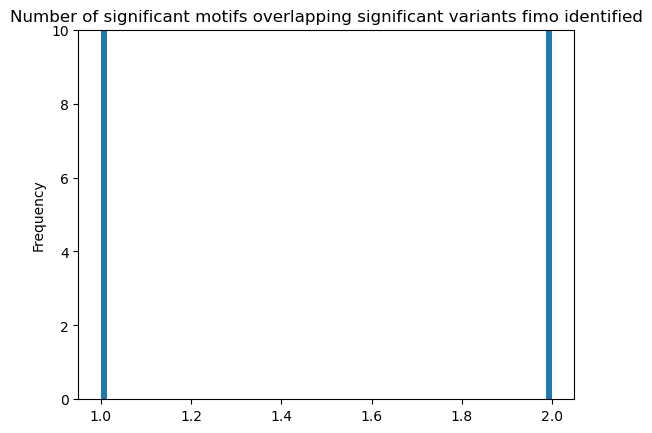

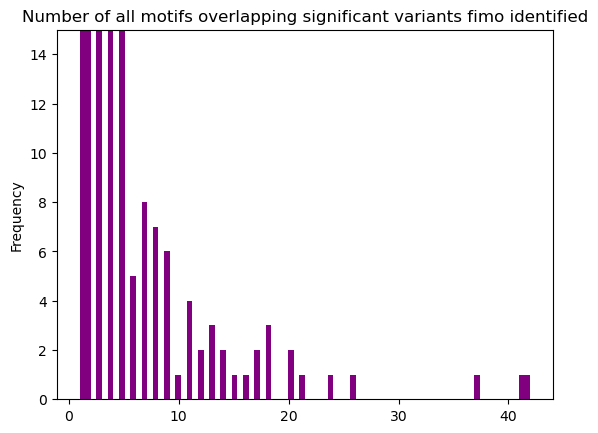

fimo_result_class
alt_fimo         42
ref_alt_fimo    203
ref_fimo          4
Name: ID, dtype: int64
fimo_significant_result_class
alt_fimo        135
ref_alt_fimo     77
ref_fimo         37
Name: ID, dtype: int64


In [83]:
significant_neuro_variants_fimo = significant_neuro_variants_fimo_filtered
# split into the 3 cases already:
# ref and alt finding
# only ref finding
# only alt finding
significant_neuro_variants_fimo['fimo_result_class'] = significant_neuro_variants_fimo.apply(lambda x: add_class_to_fimo_result_table(x), axis=1)
significant_neuro_variants_fimo['fimo_result_class'].value_counts()

# significant variants without fimo results
significant_neuro_variants_withtout_fimo_results = significant_neuro_variants_fimo.loc[significant_neuro_variants_fimo['fimo_result_class'] == 'no_fimo']
# if unique number is equal to number of variants without fimo results => continue else raise error
if significant_neuro_variants_withtout_fimo_results.shape[0] != significant_neuro_variants_withtout_fimo_results['ID'].nunique():
    raise ValueError('Not all variants without fimo results are unique. This is unexpected.')

# get only results which have fimo results0
significant_neuro_variants_fimo_results = significant_neuro_variants_fimo.loc[significant_neuro_variants_fimo['fimo_result_class'] != 'no_fimo']
significant_neuro_variants_fimo_results

# filter the results down for variant pos overlapping with fimo start and end
significant_neuro_variants_fimo_results['is_overlapping_ref'] = significant_neuro_variants_fimo_results.apply(lambda x: check_motif_overlapping_variant_pos(x), axis=1)
significant_neuro_variants_fimo_results['is_overlapping_alt'] = significant_neuro_variants_fimo_results.apply(lambda x: check_motif_overlapping_variant_pos(x, start_column='liftover_fimo_start_alt', end_column='liftover_fimo_stop_alt'), axis=1)
significant_neuro_variants_fimo_results['is_overlapping_variant'] = significant_neuro_variants_fimo_results['is_overlapping_ref'] | significant_neuro_variants_fimo_results['is_overlapping_alt']

# significant_neuro_variants_fimo_results.groupby(['ID', 'REF', 'ALT']).size() # 266
# filter for is_overlapping_variant
significant_neuro_variants_fimo_results_overlapping_variants = significant_neuro_variants_fimo_results.loc[significant_neuro_variants_fimo_results['is_overlapping_variant']]
significant_neuro_variants_fimo_results_overlapping_variants # 978, initial filtering: 323
number_of_motifs_overlapping_significant_variants_all_fimo = significant_neuro_variants_fimo_results_overlapping_variants.groupby(['ID', 'REF', 'ALT']).size() # 263, initial filtering: 212
number_of_motifs_overlapping_significant_variants_all_fimo
significant_neuro_variants_fimo_results_overlapping_variants.groupby(['fimo_result_class'])['ID'].nunique()
# without initial filtering:
# alt_fimo         72
# ref_alt_fimo    134
# ref_fimo         57

# with initial filtering:
# alt_fimo        72
# ref_alt_fimo    83
# ref_fimo        57
fimo_significants_threshold = 0.05
# # check if ref motif hit is significant and if alt motif is significant
significant_neuro_variants_fimo_results_overlapping_variants['fimo_hit_ref_is_significant'] = significant_neuro_variants_fimo_results_overlapping_variants['q-value_ref_fimo'] < fimo_significants_threshold
significant_neuro_variants_fimo_results_overlapping_variants['fimo_hit_alt_is_significant'] = significant_neuro_variants_fimo_results_overlapping_variants['q-value_alt_fimo'] < fimo_significants_threshold
significant_neuro_variants_fimo_results_overlapping_variants['fimo_hit_is_significant_at_least_once'] = significant_neuro_variants_fimo_results_overlapping_variants['fimo_hit_ref_is_significant'] | significant_neuro_variants_fimo_results_overlapping_variants['fimo_hit_alt_is_significant']
significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo = significant_neuro_variants_fimo_results_overlapping_variants.loc[significant_neuro_variants_fimo_results_overlapping_variants['fimo_hit_is_significant_at_least_once']]
significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo['fimo_significant_result_class'] = significant_neuro_variants_fimo.apply(lambda x: add_class_to_fimo_result_table(x, column_to_check='q-value', default_suffix=['_ref_fimo', '_alt_fimo'], use_significant=True, significant_threshold=fimo_significants_threshold), axis=1)

# count the number of significant fimo hits
significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo # 360
number_of_significant_motif_hits_per_variant = significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo.groupby(['ID', 'REF', 'ALT', 'motif_id_alt_fimo', 'motif_id_ref_fimo']).size() # 0.01: 10, 0.05: 53, with 0.1: 96
print(f"Number of significant variants with at least one significant motif: {significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo['ID'].nunique()} ({significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo.shape[0]} total)")
significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo.groupby(['fimo_result_class'])['ID'].size()
significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo.groupby(['fimo_significant_result_class'])['ID'].size()
# alt_fimo        13
# ref_alt_fimo    34
# ref_fimo         6

# with empty ref method: 0.01: 17, 0.05: 62, 0.1: 116
# 0.05:
# fimo_result_class
# alt_fimo        69
# ref_alt_fimo    43
# ref_fimo         6


# significants_check:
# fimo_significant_result_class
# alt_fimo        81 = 69 (ref: NA) + 12 (ref q-value > 0.05)
# ref_alt_fimo    22 = 43 (information for ref and alt) - 9 alt (q-value > 0.05) - 12 ref (q-value > 0.05)
# ref_fimo        15 6 (alt: NA) + 9 (alt q-value > 0.05)

# window size 8 41

# plot the number of significant motif hits per variant with y-max = 10
number_of_significant_motif_hits_per_variant.plot.hist(bins=80, title='Number of significant motifs overlapping significant variants fimo identified')
plt.ylim(0, 10)
plt.show()
number_of_motifs_overlapping_significant_variants_all_fimo.plot.hist(bins=80, title='Number of all motifs overlapping significant variants fimo identified', color='purple')
plt.ylim(0, 15)
plt.show()
# boxplot = number_of_significant_motif_hits_per_variant.plot(kind='box', title='Number of significant motif hits per variant')
print(significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo.groupby(['fimo_result_class'])['ID'].size())
print(significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo.groupby(['fimo_significant_result_class'])['ID'].size())


In [84]:
significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo.columns

Index(['SPDI', 'ID', 'REF', 'ALT', 'reference_activity_BCalm_logFC',
       'variant_effect_BCalm_logFC', 'variant_effect_BCalm_adj_p_Val',
       'REF_sequence', 'ALT_sequence', 'variant_pos', 'tmp_gene_name',
       'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random',
       'is_significant', 'fimo_ref_sequence', 'fimo_alt_sequence',
       'tmp_no_lable_name', 'ID_ref', 'ID_alt', 'motif_id_ref_fimo',
       'sequence_name_ref_fimo', 'start_ref_fimo', 'stop_ref_fimo',
       'strand_ref_fimo', 'q-value_ref_fimo', 'matched_sequence_ref_fimo',
       'motif_id_alt_fimo', 'sequence_name_alt_fimo', 'start_alt_fimo',
       'stop_alt_fimo', 'strand_alt_fimo', 'q-value_alt_fimo',
       'matched_sequence_alt_fimo', 'liftover_fimo_start_ref',
       'liftover_fimo_stop_ref', 'liftover_fimo_start_alt',
       'liftover_fimo_stop_alt', 'motif_is_found_in_ref_and_alt',
       'is_duplicated_alt_motif', 'fimo_result_class', 'is_overlapping_ref',
       'is_overlapping_alt', 'is_ove

Investigate the variant with the highest number of significant motifs spanning the variant position

In [85]:

# get the id of the variant with most significant motif hits
number_of_significant_motif_hits_per_variant.idxmax() # cardiac_neuro_cava_random:DRD4|ENSG00000069696.7|EH38E2937738|11-588289-T-C cardiac_neuro_cava_random:MEIS2|ENSG00000134138.22|EH38E3127701|15-36888183-G-C, 'cardiac_neuro_cava_random:MEIS2|ENSG00000134138.22|EH38E3127701|15-36888183-G-C'
number_of_significant_motif_hits_per_variant.max() # 9

significant_variant_example_overlapped_by_85_motifs = significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo.loc[significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo['ID'] == 'cardiac_neuro_cava_random:DRD4|ENSG00000069696.7|EH38E2937738|11-588289-T-C']
significant_variant_example_overlapped_by_85_motifs[['ID', 'REF', 'ALT', 'motif_id_alt_fimo', 'motif_id_ref_fimo', 'liftover_fimo_start_ref', 'liftover_fimo_stop_ref', 'liftover_fimo_start_alt', 'liftover_fimo_stop_alt']]
# significant_variant_example_overlapped_by_85_motifs['motif_id_ref_fimo'].nunique() # 10
# significant_variant_example_overlapped_by_85_motifs['motif_id_alt_fimo'].nunique() # 9
# set_significant_variant_example_overlapped_by_85_motifs_ref = set(significant_variant_example_overlapped_by_85_motifs['motif_id_ref_fimo'].to_list())
# set_significant_variant_example_overlapped_by_85_motifs_alt = set(significant_variant_example_overlapped_by_85_motifs['motif_id_alt_fimo'].to_list())

# # check union of the two sets
# set_significant_variant_example_overlapped_by_85_motifs_ref.union(set_significant_variant_example_overlapped_by_85_motifs_alt)

,ID,REF,ALT,motif_id_alt_fimo,motif_id_ref_fimo,liftover_fimo_start_ref,liftover_fimo_stop_ref,liftover_fimo_start_alt,liftover_fimo_stop_alt
1702,cardiac_neuro_cava_random:DRD4|ENSG00000069696...,cardiac_neuro_cava_random:REF_DRD4|ENSG0000006...,cardiac_neuro_cava_random:ALT_DRD4|ENSG0000006...,MA0018.4_CREB1,MA0018.4_CREB1,230.0,242.0,230.0,242.0
1714,cardiac_neuro_cava_random:DRD4|ENSG00000069696...,cardiac_neuro_cava_random:REF_DRD4|ENSG0000006...,cardiac_neuro_cava_random:ALT_DRD4|ENSG0000006...,MA0609.2_CREM,MA0609.2_CREM,229.0,244.0,229.0,244.0
1761,cardiac_neuro_cava_random:DRD4|ENSG00000069696...,cardiac_neuro_cava_random:REF_DRD4|ENSG0000006...,cardiac_neuro_cava_random:ALT_DRD4|ENSG0000006...,MA0609.2_CREM,MA0609.2_CREM,229.0,244.0,229.0,244.0
1809,cardiac_neuro_cava_random:DRD4|ENSG00000069696...,cardiac_neuro_cava_random:REF_DRD4|ENSG0000006...,cardiac_neuro_cava_random:ALT_DRD4|ENSG0000006...,MA1145.1_FOSL2::JUND,MA1145.1_FOSL2::JUND,229.0,243.0,229.0,243.0
1858,cardiac_neuro_cava_random:DRD4|ENSG00000069696...,cardiac_neuro_cava_random:REF_DRD4|ENSG0000006...,cardiac_neuro_cava_random:ALT_DRD4|ENSG0000006...,MA0605.2_ATF3,MA0605.2_ATF3,231.0,242.0,231.0,242.0
1911,cardiac_neuro_cava_random:DRD4|ENSG00000069696...,cardiac_neuro_cava_random:REF_DRD4|ENSG0000006...,cardiac_neuro_cava_random:ALT_DRD4|ENSG0000006...,MA1131.1_FOSL2::JUN,MA1131.1_FOSL2::JUN,232.0,242.0,232.0,242.0
1951,cardiac_neuro_cava_random:DRD4|ENSG00000069696...,cardiac_neuro_cava_random:REF_DRD4|ENSG0000006...,cardiac_neuro_cava_random:ALT_DRD4|ENSG0000006...,MA0605.2_ATF3,MA0605.2_ATF3,231.0,242.0,231.0,242.0
1995,cardiac_neuro_cava_random:DRD4|ENSG00000069696...,cardiac_neuro_cava_random:REF_DRD4|ENSG0000006...,cardiac_neuro_cava_random:ALT_DRD4|ENSG0000006...,MA1951.1_FOS,MA1951.1_FOS,230.0,243.0,230.0,243.0
2040,cardiac_neuro_cava_random:DRD4|ENSG00000069696...,cardiac_neuro_cava_random:REF_DRD4|ENSG0000006...,cardiac_neuro_cava_random:ALT_DRD4|ENSG0000006...,MA1475.1_CREB3L4,MA1475.1_CREB3L4,231.0,242.0,231.0,242.0
2090,cardiac_neuro_cava_random:DRD4|ENSG00000069696...,cardiac_neuro_cava_random:REF_DRD4|ENSG0000006...,cardiac_neuro_cava_random:ALT_DRD4|ENSG0000006...,MA1127.1_FOSB::JUN,MA1127.1_FOSB::JUN,232.0,242.0,232.0,242.0


##### Make input for plotting the motifs back to the sequences (Split the fimo variant table into different tables)
- easily possible for the cases where the motif is found within both sequences because I can just give any of the fimo columns 
- for the knock-in and knockout cases I need to create the resulting dataframe with more caution 
  - if the fimo result is only available for the alt, I can only take the alt columns (from fimo results)
  - if the fimo result is only available for the ref, I can only take the ref columns (from fimo results)  

In [86]:
col_alt_id = 'tmp_variant_fimo_hit_ALT_ID'
col_ref_id = 'tmp_variant_fimo_hit_REF_ID'
col_variant_pos = 'tmp_variant_fimo_hit_variant_pos'
col_motif_id = 'tmp_fimo_results_motif_id'
col_start = 'tmp_fimo_results_start'
col_stop = 'tmp_fimo_results_stop'
col_strand = 'tmp_fimo_results_strand'
col_fimo_q_value = 'tmp_fimo_results_q-value'
col_fimo_matched_sequence = 'tmp_fimo_results_matched_sequence'
col_ref_sequence = 'ref_sequence'
col_alt_sequence = 'alt_sequence'
col_mpralm_logFC = 'tmp_variant_BECALM_logFC'

Split the variant table based fimo result table into different tables: based on the amount of fimo results (only ref, only alt or both: ref and alt)
- for both it is easy to plot: because any of the fimo columns can be taken
- for only ref: I need to take the fimo_ref columns 
- for only alt: I need to take the fimo_alt columns

In [87]:
sig_variant_sig_fimo_ref_alt = significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo.loc[significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo['fimo_result_class'] == 'ref_alt_fimo']
print(f"Number of significant variants with significant fimo hits with motifs found within REF and ALT (at least one of these motifs is a significant hit): {sig_variant_sig_fimo_ref_alt['ID'].nunique()} ({sig_variant_sig_fimo_ref_alt.shape[0]} total)")
sig_variant_sig_fimo_only_ref = significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo.loc[significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo['fimo_result_class'] == 'ref_fimo']
print(f"Number of significant variants with significant fimo hits with motifs found within REF only (at least one of these motifs is a significant hit): {sig_variant_sig_fimo_only_ref['ID'].nunique()} ({sig_variant_sig_fimo_only_ref.shape[0]} total)")
sig_variant_sig_fimo_only_alt = significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo.loc[significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo['fimo_result_class'] == 'alt_fimo']
print(f"Number of significant variants with significant fimo hits with motifs found within ALT only (at least one of these motifs is a significant hit): {sig_variant_sig_fimo_only_alt['ID'].nunique()} ({sig_variant_sig_fimo_only_alt.shape[0]} total)")


Number of significant variants with significant fimo hits with motifs found within REF and ALT (at least one of these motifs is a significant hit): 64 (203 total)
Number of significant variants with significant fimo hits with motifs found within REF only (at least one of these motifs is a significant hit): 4 (4 total)
Number of significant variants with significant fimo hits with motifs found within ALT only (at least one of these motifs is a significant hit): 24 (42 total)


In [88]:
# # sanity checking the window size:
# cardiac_neuro_cava_random:ALT_KMT5B|ENSG00000110066.16|EH38E1547688_rev_tile1-1_KMT5B|ENSG00000110066.16|EH38E1547688|11-68138514-G-A
# # TCCTGTTTCCATTGAAAACAG
significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo.loc[significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo['ALT'].str.contains('cardiac_neuro_cava_random:ALT_KMT5B|ENSG00000110066.16|EH38E1547688_rev_tile1-1_KMT5B|ENSG00000110066.16|EH38E1547688|11-68138514-G-A')]['fimo_ref_sequence']

3601    TGCCAGCTGGCAGGAGGAGCC
3619    TGCCAGCTGGCAGGAGGAGCC
3637    TGCCAGCTGGCAGGAGGAGCC
3655    TGCCAGCTGGCAGGAGGAGCC
Name: fimo_ref_sequence, dtype: object

Make the easy case first: significant motif hits within ref and alt sequence

In [90]:
# get the columns of interest:
significant_neuro_variants_fimo_results_overlapping_variants_significant_fimo.columns

columns_for_plotting = ['REF', 'ALT', 'variant_pos', 'motif_id_alt_fimo', 'liftover_fimo_start_alt', 'liftover_fimo_stop_alt', 'strand_alt_fimo', 'q-value_alt_fimo', 'q-value_ref_fimo', 'matched_sequence_alt_fimo', 'REF_sequence', 'ALT_sequence',  'variant_effect_BCalm_logFC']

sig_variant_sig_fimo_ref_alt_plotting_ready = sig_variant_sig_fimo_ref_alt[columns_for_plotting]
sig_variant_sig_fimo_ref_alt_plotting_ready.head()
# make variant pos to integer
sig_variant_sig_fimo_ref_alt_plotting_ready['variant_pos'] = sig_variant_sig_fimo_ref_alt_plotting_ready['variant_pos'].apply(lambda x: x[0])

# rename columns
sig_variant_sig_fimo_ref_alt_plotting_ready = sig_variant_sig_fimo_ref_alt_plotting_ready.rename(columns={'ALT': col_alt_id, 'REF': col_ref_id, 'variant_pos': col_variant_pos, 'motif_id_alt_fimo': col_motif_id, 'liftover_fimo_start_alt': col_start, 'liftover_fimo_stop_alt': col_stop, 'strand_alt_fimo': col_strand, 'q-value_alt_fimo': col_fimo_q_value, 'matched_sequence_alt_fimo': col_fimo_matched_sequence, 'ALT_sequence': col_alt_sequence , 'REF_sequence': col_ref_sequence, 'variant_effect_BCalm_logFC': col_mpralm_logFC})
sig_variant_sig_fimo_ref_alt_plotting_ready_sorted_by_variant_effect_and_alt_id = sig_variant_sig_fimo_ref_alt_plotting_ready.sort_values([col_mpralm_logFC,col_alt_id], ascending=[False, True])
# write to file:
# sig_variant_sig_fimo_ref_alt_plotting_ready_sorted_by_variant_effect_and_alt_id.to_csv(os.path.join(config['files']['creating']['fimo_neuro_variant_output_dir'], f'significant_variant_fimo_hits_both_ref_alt_plotting_{motif_set_name}_{sig_variant_sig_fimo_ref_alt_plotting_ready.shape[0]}.tsv'), sep="\t", index=False)
print(f"Wrote to: {os.path.join(config['files']['creating']['fimo_neuro_variant_output_dir'], f'significant_variant_fimo_hits_both_ref_alt_plotting_{motif_set_name}_{sig_variant_sig_fimo_ref_alt_plotting_ready.shape[0]}.tsv')}")
sig_variant_sig_fimo_ref_alt_plotting_ready_sorted_by_variant_effect_and_alt_id.head()

Wrote to: /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/neuro_fimo_significant/significant_variant_fimo_hits_both_ref_alt_plotting_JASPAR2022_203.tsv


/tmp/ipykernel_41356/2488525911.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sig_variant_sig_fimo_ref_alt_plotting_ready['variant_pos'] = sig_variant_sig_fimo_ref_alt_plotting_ready['variant_pos'].apply(lambda x: x[0])


,tmp_variant_fimo_hit_REF_ID,tmp_variant_fimo_hit_ALT_ID,tmp_variant_fimo_hit_variant_pos,tmp_fimo_results_motif_id,tmp_fimo_results_start,tmp_fimo_results_stop,tmp_fimo_results_strand,tmp_fimo_results_q-value,q-value_ref_fimo,tmp_fimo_results_matched_sequence,ref_sequence,alt_sequence,tmp_variant_BECALM_logFC
566,cardiac_neuro_cava_random:REF_CHI3L1|ENSG00000...,cardiac_neuro_cava_random:ALT_CHI3L1|ENSG00000...,224,MA0093.3_USF1,217.0,230.0,-,0.04090,0.0502,AGCCCACGTGACCC,CAGAAATGAAGGTGGGGTTGGAGAAGGAGAACCGGCCTCCTCAGAG...,CAGAAATGAAGGTGGGGTTGGAGAAGGAGAACCGGCCTCCTCAGAG...,0.918080
9950,cardiac_neuro_cava_random:REF_DALRD3|ENSG00000...,cardiac_neuro_cava_random:ALT_DALRD3|ENSG00000...,231,MA0609.2_CREM,223.0,238.0,+,0.00845,0.0616,GGCCTGACGTCAGTGC,CCTCTTCCTTCTGGGGTGCTGATAGGGCAGGACCTTCTTCCCTAGG...,CCTCTTCCTTCTGGGGTGCTGATAGGGCAGGACCTTCTTCCCTAGG...,0.883350
9976,cardiac_neuro_cava_random:REF_DALRD3|ENSG00000...,cardiac_neuro_cava_random:ALT_DALRD3|ENSG00000...,231,MA0609.2_CREM,223.0,238.0,-,0.00845,0.0616,GCACTGACGTCAGGCC,CCTCTTCCTTCTGGGGTGCTGATAGGGCAGGACCTTCTTCCCTAGG...,CCTCTTCCTTCTGGGGTGCTGATAGGGCAGGACCTTCTTCCCTAGG...,0.883350
8488,cardiac_neuro_cava_random:REF_LZTR1|ENSG000000...,cardiac_neuro_cava_random:ALT_LZTR1|ENSG000000...,196,MA0065.2_Pparg::Rxra,191.0,205.0,+,0.01160,0.0116,TGAGGTCAGAGGGCA,TCCATCCCCATCTTTGTCTGCTTGTCGAACTTCAGAAATCTGCAAG...,TCCATCCCCATCTTTGTCTGCTTGTCGAACTTCAGAAATCTGCAAG...,0.649552
8503,cardiac_neuro_cava_random:REF_LZTR1|ENSG000000...,cardiac_neuro_cava_random:ALT_LZTR1|ENSG000000...,196,MA1537.1_NR2F1,192.0,206.0,+,0.00554,0.0288,GAGGTCAGAGGGCAG,TCCATCCCCATCTTTGTCTGCTTGTCGAACTTCAGAAATCTGCAAG...,TCCATCCCCATCTTTGTCTGCTTGTCGAACTTCAGAAATCTGCAAG...,0.649552


#### Running the plotting function
- for both ref and alt hits: 
  - python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/plot_alignment_withPWM_thorben.py --aligMotifFile /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/neuro_fimo_significant/significant_variant_fimo_hits_both_ref_alt_plotting_43.csv --PWMsFile /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme --chunk_size 1 --output /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/neuro_fimo_significant/plot_significant_variants_hit_unique
  - python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/plot_alignment_withPWM_thorben.py --aligMotifFile /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/neuro_fimo_significant/significant_variant_fimo_hits_both_ref_alt_plotting_49.tsv --PWMsFile /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme --chunk_size 1 --variantEffectColumn tmp_variant_BECALM_logFC --plottingBackground 0.1 --variantPosZeroBased True --output /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/neuro_fimo_significant/plot_variants_improved_fimo_both_ref_alt_logFC_all_motifs_H12Core_bg_01_window_10
  - corrected lift over:
  - python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/plot_alignment_withPWM_thorben.py --aligMotifFile /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/neuro_fimo_significant/significant_variant_fimo_hits_both_ref_alt_plotting_51.tsv --PWMsFile /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme --chunk_size 1 --variantEffectColumn tmp_variant_BECALM_logFC --plottingBackground 0.1 --variantPosZeroBased True --output /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/neuro_fimo_significant/plot_variants_improved_fimo_both_ref_alt_logFC_all_motifs_H12Core_bg_01_window_10
  - python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/plot_alignment_withPWM_thorben.py --aligMotifFile /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/neuro_fimo_significant/significant_variant_fimo_hits_both_ref_alt_plotting_JASPAR2022_203.tsv --PWMsFile /data/cephfs-2/unmirrored/groups/kircher/Kaikkonen_2023/filesFromMinnaKaikkonen/github_repo/STARseqCNN/JASPAR2022_CORE_vertebrates_non-redundant_pfms_meme_nice.txt --chunk_size 1 --variantEffectColumn tmp_variant_BECALM_logFC --plottingBackground 0.1 --variantPosZeroBased True --output /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/neuro_fimo_significant/plot_variants_improved_fimo_both_ref_alt_logFC_all_motifs_H12Core_bg_01_window_10_jaspar2022
  

In [38]:
print(os.path.join(config['files']['creating']['fimo_neuro_variant_output_dir'], f'significant_variant_fimo_hits_both_ref_alt_plotting_{sig_variant_sig_fimo_ref_alt_plotting_ready.shape[0]}.csv'))

/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/neuro_fimo_significant/significant_variant_fimo_hits_both_ref_alt_plotting_51.csv


In [39]:
# significant_neuro_variants_fimo_results_both.columns
# list_of_interesting_columns = ['ID', 'variant_pos', 'start_alt_fimo', 'stop_alt_fimo', 'liftover_fimo_start_alt', 'liftover_fimo_stop_alt', 'is_overlapping_alt']
# significant_neuro_variants_fimo_results_both[list_of_interesting_columns].loc[~significant_neuro_variants_fimo_results_both['is_overlapping_alt']]
# significant_neuro_variants_fimo_results_both[list_of_interesting_columns].loc[significant_neuro_variants_fimo_results_both['ID'].str.contains('cardiac_neuro_cava_random:FOXP2|ENSG00000128573.28|EH38E2583028|7-114533428-G-T')]


NameError: name 'significant_neuro_variants_fimo_results_both' is not defined

In [284]:
# check how many have both ref and alt fimo results
significant_neuro_variants_fimo['sequence_name_ref_fimo'].notna().sum() # 980
significant_neuro_variants_fimo['sequence_name_alt_fimo'].notna().sum() # 980
significant_neuro_variants_fimo['ID'].shape[0] # 1151
significant_neuro_variants_fimo['ID'].nunique() # 374

significant_neuro_variants_fimo.groupby(['ID'])

In [91]:
significant_neuro_variants_fimo['ref_is_na'] = significant_neuro_variants_fimo['sequence_name_ref_fimo'].isna()
significant_neuro_variants_fimo['alt_is_na'] = significant_neuro_variants_fimo['sequence_name_alt_fimo'].isna()
significant_neuro_variants_fimo['no_fimo_results'] = significant_neuro_variants_fimo['ref_is_na'] & significant_neuro_variants_fimo['alt_is_na']
# remove all variants without any fimo result
no_fimo_result_IDs = significant_neuro_variants_fimo.loc[significant_neuro_variants_fimo['no_fimo_results']]['ID'].unique()
no_fimo_result_table = significant_neuro_variants_fimo.loc[significant_neuro_variants_fimo['ID'].isin(no_fimo_result_IDs)]
print("Number of significant variants without a finding from Fimo: ", no_fimo_result_table['ID'].nunique()) # 171

significant_variant_fimo_result_table = significant_neuro_variants_fimo.loc[~significant_neuro_variants_fimo['ID'].isin(no_fimo_result_IDs)]
print("Number of significant variants with a finding from Fimo: ", significant_variant_fimo_result_table['ID'].nunique()) # 203
significant_variant_fimo_result_table # 980
#

Number of significant variants without a finding from Fimo:  0
Number of significant variants with a finding from Fimo:  267


,SPDI,ID,REF,ALT,reference_activity_BCalm_logFC,variant_effect_BCalm_logFC,variant_effect_BCalm_adj_p_Val,REF_sequence,ALT_sequence,variant_pos,...,liftover_fimo_start_ref,liftover_fimo_stop_ref,liftover_fimo_start_alt,liftover_fimo_stop_alt,motif_is_found_in_ref_and_alt,is_duplicated_alt_motif,fimo_result_class,ref_is_na,alt_is_na,no_fimo_results
2,NC_000001.11:2288507:G:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.189602,0.628996,1.682864e-17,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,[125],...,122.0,135.0,122.0,135.0,True,False,ref_alt_fimo,False,False,False
18,NC_000001.11:2288507:G:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.189602,0.628996,1.682864e-17,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,[125],...,121.0,135.0,121.0,135.0,True,False,ref_alt_fimo,False,False,False
30,NC_000001.11:2288507:G:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.189602,0.628996,1.682864e-17,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,[125],...,122.0,135.0,122.0,135.0,True,False,ref_alt_fimo,False,False,False
48,NC_000001.11:2288507:G:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.189602,0.628996,1.682864e-17,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,[125],...,124.0,134.0,124.0,134.0,True,False,ref_alt_fimo,False,False,False
60,NC_000001.11:2288507:G:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.189602,0.628996,1.682864e-17,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,[125],...,124.0,133.0,124.0,133.0,True,False,ref_alt_fimo,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18781,NC_000023.11:154000203:C:T,cardiac_neuro_cava_random:MECP2|ENSG0000016905...,cardiac_neuro_cava_random:REF_MECP2|ENSG000001...,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,0.789574,0.268555,8.002922e-03,AGGTCCCCAGGCTGCTCCATGTGACAGGCACAACCCATCCCCAGTG...,AGGTCCCCAGGCTGCTCCATGTGACAGGCACAACCCATCCCCAGTG...,[191],...,NaN,NaN,185.0,200.0,False,False,alt_fimo,False,False,False
18784,NC_000023.11:154000203:C:T,cardiac_neuro_cava_random:MECP2|ENSG0000016905...,cardiac_neuro_cava_random:REF_MECP2|ENSG000001...,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,0.789574,0.268555,8.002922e-03,AGGTCCCCAGGCTGCTCCATGTGACAGGCACAACCCATCCCCAGTG...,AGGTCCCCAGGCTGCTCCATGTGACAGGCACAACCCATCCCCAGTG...,[191],...,NaN,NaN,188.0,197.0,False,False,alt_fimo,False,False,False
18787,NC_000023.11:154000203:C:T,cardiac_neuro_cava_random:MECP2|ENSG0000016905...,cardiac_neuro_cava_random:REF_MECP2|ENSG000001...,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,0.789574,0.268555,8.002922e-03,AGGTCCCCAGGCTGCTCCATGTGACAGGCACAACCCATCCCCAGTG...,AGGTCCCCAGGCTGCTCCATGTGACAGGCACAACCCATCCCCAGTG...,[191],...,NaN,NaN,188.0,197.0,False,False,alt_fimo,False,False,False
18788,NC_000023.11:154000203:C:T,cardiac_neuro_cava_random:MECP2|ENSG0000016905...,cardiac_neuro_cava_random:REF_MECP2|ENSG000001...,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,0.789574,0.268555,8.002922e-03,AGGTCCCCAGGCTGCTCCATGTGACAGGCACAACCCATCCCCAGTG...,AGGTCCCCAGGCTGCTCCATGTGACAGGCACAACCCATCCCCAGTG...,[191],...,NaN,NaN,188.0,197.0,False,False,alt_fimo,False,False,False


In [92]:
neuro_variants_with_ref_and_alt_fimo_result = significant_neuro_variants_fimo.groupby(['ID', 'sequence_name_ref_fimo', 'sequence_name_alt_fimo']).size().reset_index(name='counts') # 203 different variants with a result
neuro_variants_with_fimo_results = significant_neuro_variants_fimo.groupby(['ID']).size().reset_index(name='counts') # 203 different variants with a result

In [287]:
neuro_variants_with_ref_and_alt_fimo_result

,ID,sequence_name_ref_fimo,sequence_name_alt_fimo,counts
0,cardiac_neuro_cava_random:ADAM22|ENSG000000082...,ADAM22|ENSG00000008277.15|EH38E3784594|7-88218...,ADAM22|ENSG00000008277.15|EH38E3784594|7-88218...,2
1,cardiac_neuro_cava_random:ADNP|ENSG00000101126...,ADNP|ENSG00000101126.18|EH38E3439775|20-508714...,ADNP|ENSG00000101126.18|EH38E3439775|20-508714...,3
2,cardiac_neuro_cava_random:ADSL|ENSG00000239900...,ADSL|ENSG00000239900.14|EH38E3482827|22-404021...,ADSL|ENSG00000239900.14|EH38E3482827|22-404021...,4
3,cardiac_neuro_cava_random:ANK2|ENSG00000145362...,ANK2|ENSG00000145362.21|EH38E2320911|4-1128946...,ANK2|ENSG00000145362.21|EH38E2320911|4-1128946...,3
4,cardiac_neuro_cava_random:ANK2|ENSG00000145362...,ANK2|ENSG00000145362.21|EH38E2320911|4-1128947...,ANK2|ENSG00000145362.21|EH38E2320911|4-1128947...,2
...,...,...,...,...
131,cardiac_neuro_cava_random:WWOX|ENSG00000186153...,WWOX|ENSG00000186153.18|EH38E3192275|16-786115...,WWOX|ENSG00000186153.18|EH38E3192275|16-786115...,2
132,cardiac_neuro_cava_random:WWOX|ENSG00000186153...,WWOX|ENSG00000186153.18|EH38E3192398|16-788934...,WWOX|ENSG00000186153.18|EH38E3192398|16-788934...,3
133,cardiac_neuro_cava_random:YWHAG|ENSG0000017002...,YWHAG|ENSG00000170027.7|EH38E2564783|7-7635561...,YWHAG|ENSG00000170027.7|EH38E2564783|7-7635561...,1
134,cardiac_neuro_cava_random:ZNF148|ENSG000001638...,ZNF148|ENSG00000163848.21|EH38E3536274|3-12521...,ZNF148|ENSG00000163848.21|EH38E3536274|3-12521...,1


In [288]:
neuro_variants_with_ref_and_alt_fimo_result['counts'].value_counts() # 203 variants have only one result

2     40
1     29
3     24
4     20
5     10
6      6
7      3
9      1
16     1
11     1
8      1
Name: counts, dtype: int64

In [289]:
neuro_variants_with_fimo_results['counts'].value_counts() #203

1     116
2      66
3      34
4      26
5      11
6       6
7       3
9       1
16      1
11      1
8       1
Name: counts, dtype: int64

In [290]:
significant_neuro_variants_fimo.columns

Index(['SPDI', 'ID', 'REF', 'ALT', 'reference_activity_BCalm_logFC',
       'variant_effect_BCalm_logFC', 'variant_effect_BCalm_adj_p_Val',
       'REF_sequence', 'ALT_sequence', 'variant_pos', 'tmp_gene_name',
       'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random',
       'is_significant', 'fimo_ref_sequence', 'fimo_alt_sequence',
       'tmp_no_lable_name', 'ID_ref', 'ID_alt', 'motif_id_ref_fimo',
       'sequence_name_ref_fimo', 'start_ref_fimo', 'stop_ref_fimo',
       'strand_ref_fimo', 'q-value_ref_fimo', 'matched_sequence_ref_fimo',
       'motif_id_alt_fimo', 'sequence_name_alt_fimo', 'start_alt_fimo',
       'stop_alt_fimo', 'strand_alt_fimo', 'q-value_alt_fimo',
       'matched_sequence_alt_fimo', 'liftover_fimo_start_ref',
       'liftover_fimo_stop_ref', 'liftover_fimo_start_alt',
       'liftover_fimo_stop_alt', 'fimo_result_class', 'ref_is_na', 'alt_is_na',
       'no_fimo_results'],
      dtype='object')

#### investigate fimo results

In [34]:
print('-------\tinvestigating fimo results: ')
# print number of all fimo findings
print(f'Number of all fimo findings: {fimo_results.shape[0]}')
# findings in different sequences
# fimo_results['sequence_name'].value_counts()
print(f'Hits in {fimo_results["sequence_name"].nunique()} different sequences') # 406

# print number of different motifs:
print(f'Number of different motifs found: {fimo_results["motif_id"].nunique()}') # 185 different motifs

print('-------\tFilter fimo table for significant hits: ')

q_value_threshold = 0.01
significant_fimo_results = fimo_results[fimo_results['q-value'] < q_value_threshold]
print(f'Number of significant fimo findings: {significant_fimo_results.shape[0]}') # 34
# findings in different sequences
# significant_fimo_results['sequence_name'].value_counts()
print(f'Significant hits in {significant_fimo_results["sequence_name"].nunique()} different sequences') # 32

# print number of different motifs:
print(f'Number of different motifs found: {significant_fimo_results["motif_id"].nunique()}') # 14 different motifs

significant_fimo_results


# # print number of significant results
# print('-------\tinvestigating significant results: ')
# q_value_threshold = 0.01
# significant_fimo_results = fimo_results[fimo_results['q-value'] < q_value_threshold]
# print(f'Number of significant results: {significant_fimo_results.shape[0]}')
# significant_fimo_results
# # findings in different sequences
# significant_fimo_results['sequence_name'].value_counts()
# print(f'Hits in {significant_fimo_results["sequence_name"].nunique()} different sequences')
# print(f'Hits in {significant_fimo_results.loc[significant_fimo_results["sequence_name"].str.contains("ALT_")]["sequence_name"].nunique()} different alternative sequences')
# print(f'Hits in {significant_fimo_results.loc[significant_fimo_results["sequence_name"].str.contains("REF_")]["sequence_name"].nunique()} different reference sequences')

# # print number of different motifs:
# print(f'Number of different motifs: {significant_fimo_results["motif_id"].nunique()}')
# # from my observations: max(ref, alt) + max(ref, alt)/3
# print(f'Approximitely, maximal {max(significant_fimo_results.loc[significant_fimo_results["sequence_name"].str.contains("ALT_")]["sequence_name"].nunique(), significant_fimo_results.loc[significant_fimo_results["sequence_name"].str.contains("REF_")]["sequence_name"].nunique()/2) + max(significant_fimo_results.loc[significant_fimo_results["sequence_name"].str.contains("ALT_")]["sequence_name"].nunique(), significant_fimo_results.loc[significant_fimo_results["sequence_name"].str.contains("REF_")]["sequence_name"].nunique()/2)/3} different variants with motifs')

# # sort by q-value and show the top 10
# significant_fimo_results.sort_values(by='q-value').head(10)

-------	investigating fimo results: 
Number of all fimo findings: 774
Hits in 402 different sequences
Number of different motifs found: 223
-------	Filter fimo table for significant hits: 
Number of significant fimo findings: 14
Significant hits in 13 different sequences
Number of different motifs found: 11


,motif_id,sequence_name,start,stop,strand,q-value,matched_sequence,is_reference
0,ZN282.H12CORE.0.P.B,MEIS2|ENSG00000134138.22|EH38E3127701|15-36888...,5,15,-,0.001350,GGGGCGGGAGG,False
1,ZN770.H12CORE.0.P.B,CNPY3|ENSG00000137161.18|EH38E3708669|6-429285...,2,13,-,0.001700,GGGAGGCCGAGG,True
2,ZKSC1.H12CORE.0.P.B,WDFY3|ENSG00000163625.17|EH38E3592875|4-849582...,2,20,-,0.000681,TGAGCACCTACTGTGTATA,True
3,P63.H12CORE.1.PS.A,NTRK2|ENSG00000148053.18|EH38E2702625|9-848520...,6,17,-,0.007390,CCAGACATGTCC,False
5,NRF1.H12CORE.0.PS.A,PAX5|ENSG00000196092.14|EH38E3882328|9-3700750...,5,20,+,0.006380,GTCTTGCGCATGCGTG,True
6,ANDR.H12CORE.2.P.B,SLC13A5|ENSG00000141485.17|EH38E3206369|17-670...,1,19,+,0.003000,TTTGCTTCCTTGTTTGCAT,False
7,ZBT14.H12CORE.1.S.B,SMARCA4|ENSG00000127616.21|EH38E3290033|19-109...,1,16,+,0.007610,GCGCGCGCGCATGTGT,False
9,ZSC22.H12CORE.0.P.C,MEIS2|ENSG00000134138.22|EH38E3127701|15-36888...,4,20,-,0.003340,GGGCTGGGGGGGGAGGA,True
16,ZSC22.H12CORE.0.P.C,WWOX|ENSG00000186153.18|EH38E3192275|16-786115...,2,18,-,0.003340,TGTGGGAAGGAGGAGGG,True
17,RARA.H12CORE.1.P.B,SHANK3|ENSG00000251322.11|EH38E2173330|22-5065...,2,20,+,0.004620,AGGGGTCACGTGGAGGGGT,False
